In [1]:
%load_ext autoreload
%autoreload 2 

    

In [2]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina' # high res plotting

import sys
sys.path.append('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/spikeparam')


from spikeparam.patch.fit import Spike
from spikeparam.patch.fit import SpikeGroup



from neurodsp import spectral

from scipy import signal
import scipy

import h5py
from tqdm.notebook import tqdm

import numpy as np
import pandas as pd

from neurodsp import filt
from neurodsp.timefrequency import amp_by_time, phase_by_time
from neurodsp.plts import plot_time_series, plot_instantaneous_measure
from neurodsp.plts.time_series import plot_bursts
from neurodsp.burst import detect_bursts_dual_threshold, compute_burst_stats

from scipy.signal import sosfiltfilt, butter

from scipy.signal import find_peaks
from scipy.optimize import curve_fit
from scipy.stats import pearsonr
import statsmodels.api as sm
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,  r2_score
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.cluster import MiniBatchKMeans
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Lasso, ElasticNet



import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import seaborn as sns
import scipy.stats as stats
import scipy.spatial as sp_spatial

import os
import time



from fooof import FOOOF

from sklearn.linear_model import LinearRegression

sns.set(rc={'figure.figsize':(12,9)})
sns.set_style('whitegrid')
sns.set_style("whitegrid", {'axes.grid' : False})


import warnings
warnings.filterwarnings('ignore')
os.environ['PYTHONWARNINGS'] = 'ignore'
import matplotlib.animation as animation

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


/var/folders/rr/tk8wmt7x4xlgzgmcy768y1rm0000gn/T/ipykernel_67415/3379620088.py:61: DeprecationWarning: 
The `fooof` package is being deprecated and replaced by the `specparam` (spectral parameterization) package.
This version of `fooof` (1.1) is fully functional, but will not be further updated.
New projects are recommended to update to using `specparam` (see Changelog for details).
  from fooof import FOOOF


### HELPER FUNCTIONS - to do: move to .py file 

In [3]:
def butter_bandpass(data, fs, filt_freq, order):
    # make sure that the user provides two frequencies for bandpass filter
    try:
        # renormalize frequencies in Hz to fractional scale required by butter
        nyq = 0.5 * fs # nyquist frequency
        f0 = (filt_freq[0]/nyq)
        f1 = (filt_freq[1]/nyq)

        # highpass first
        sos = butter(order, f0, btype = 'high', analog=False, output='sos')
        y = sosfiltfilt(sos, data)

        # then lowpass
        sos = butter(order, f1, btype = 'low', analog=False, output='sos')
        y = sosfiltfilt(sos, y)
        
        return y
    
    except:
        print("filt_freq must have two frequencies for a bandpass filter")

In [4]:
def get_patch_fs_metadata(metadata_file, cell_num):
    
    metafile = pd.read_excel(metadata_file, sheet_name='Sheet1')
    #get index for cell
    cells = metafile['Cell']
    index_cell = cells[cells == "c"+str(cell_num)].index[0]
    
    #get path fs for cell
    
    patch_fs = metafile['Patch Samp. Freq. (Hz)'][index_cell]
    
    return patch_fs
    

In [5]:
def upper(df):
    '''Returns the upper triangle of a correlation matrix.
    You can use scipy.spatial.distance.squareform to recreate matrix from upper triangle.
    Args:
      df: pandas or numpy correlation matrix
    Returns:
      list of values from upper triangle
    '''
    try:
        assert(type(df)==np.ndarray)
    except:
        if type(df)==pd.DataFrame:
            df = df.values
        else:
            raise TypeError('Must be np.ndarray or pd.DataFrame')
    mask = np.triu_indices(df.shape[0], k=1)
    return df[mask]

In [6]:
metadata_dir = '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Data Summary.xlsx'
patch_fs_c19 = 50023.8837632712

In [7]:
npx_fs = 30000 # sampling rate
lfp_fs = 2500 # sampling rate


npx_channels = 384
npx_patch_channel = 191

data_path = '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/all_recordings/'

out_lfp_path = '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/filt_lfp_recordings/'

out_npx_path = '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/filt_npx_recordings/'

out_patch_path = '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/filt_patch_recordings/'

cell_ids = ['c19', 'c19']

### Loading spe-1 data:

I moved the data loading steps to a separate Jupyter Notebook 

#load_spe1_data(data_path, lfp_fs, npx_fs, patch_fs, cell_ids, npx_channels, npx_patch_channel, out_lfp_path, out_npx_path, out_patch_path)



## Cell 19  (Whole patch, IC)
### Analyze Gamma LFP and whole patch clamp AP relationship for cell 19

#### Step 0: Get loaded data

In [8]:
lfp_c19= '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/filt_lfp_recordings/c19_lfp_filt.npy'
patch_c19 = '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/filt_patch_recordings/c19patch_filt.npy'


In [9]:
#get cell number 
cell_num = lfp_c19.split('/')[len(lfp_c19.split('/'))-1].split('_')[0]


#get patch data 
patch_filt_c19 = np.load(patch_c19)
patch_c19_one_ms = float(patch_fs_c19  / 1000)
patch_times_c19 = np.arange(0, np.shape(patch_filt_c19 )[0]) / patch_c19_one_ms # in ms instead of sec

### Compute patch clamp spike features for cell 19

In [10]:
#flip sign of patch filt
patch_filt_c19 = -patch_filt_c19

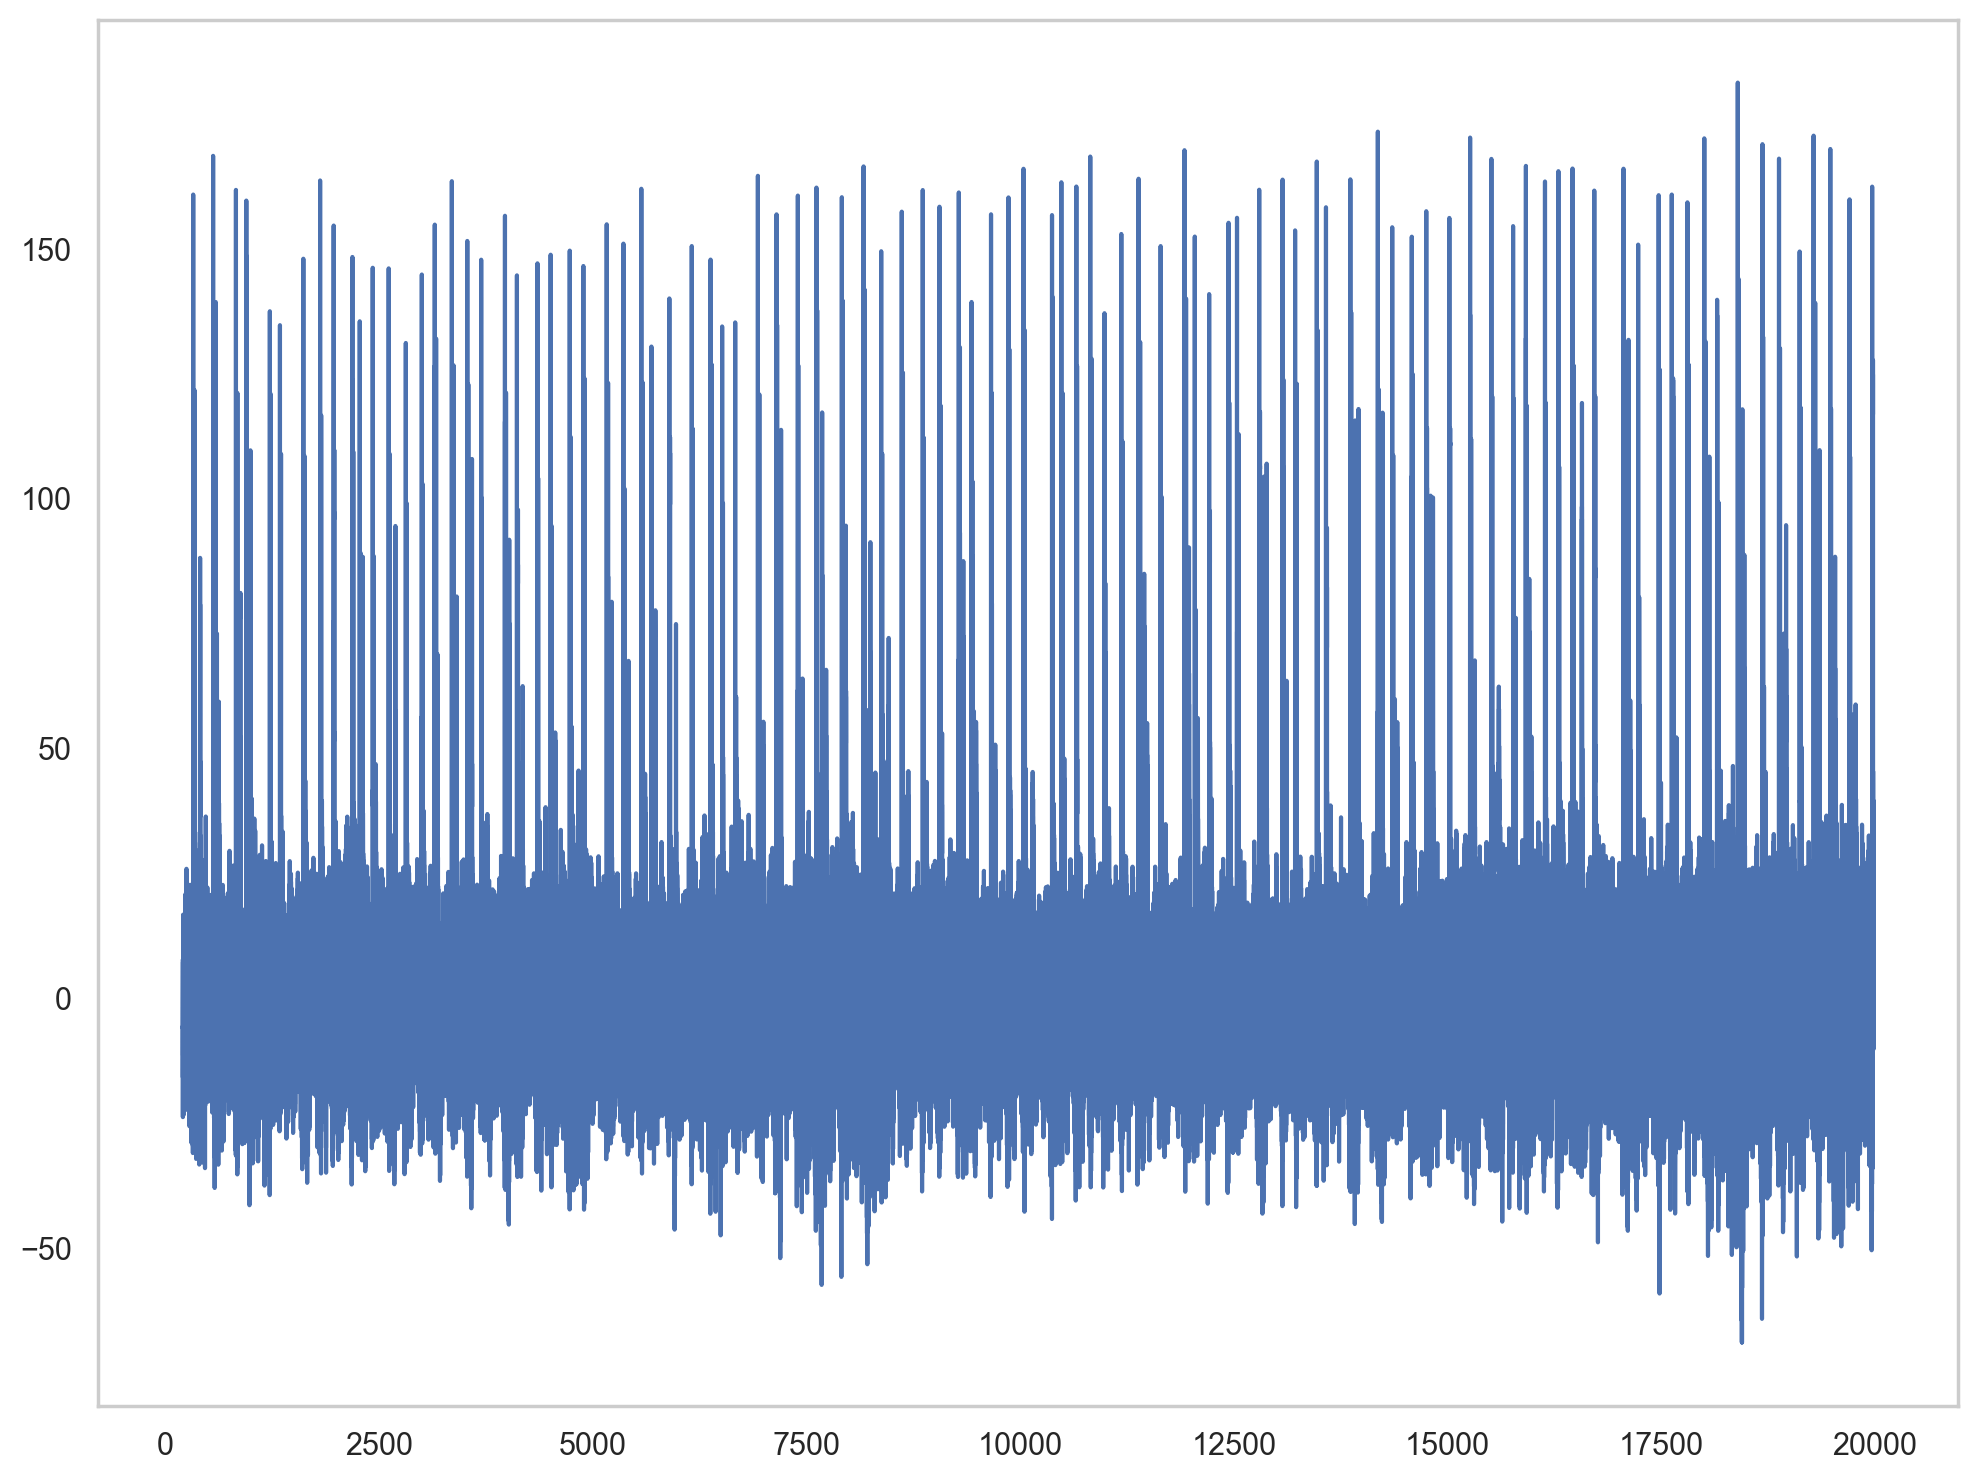

In [11]:
plt.plot(patch_times_c19[10000:1000000], patch_filt_c19[10000:1000000])

In [12]:
def compute_alt_features(stim, fs):
    return stim.mean(), stim.std()

#threshold in mVs
sp = Spike(thresh_amp=105, window_length=(5., 5.), smooth_frac=.01)

"""sp.alt(lfp_filt_c19, lfp_fs, compute_alt_features, queue=True,
       param_keys=['stim_mean', 'stim_std'], ref='inflection', window_length=(20, 0))"""

sp.fit(patch_filt_c19, patch_fs_c19, n_jobs=-1, progress=tqdm)

Spike:   0%|          | 0/8304 [00:00<?, ?it/s]

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


In [13]:
def compute_isi(spike_inds, fs, in_ms=True):
    """Compute inter-spike intervals.

    Parameters
    ----------
    spike_inds : 1d array or list of 1d array
        Sample indices where spikes occur.
    fs : float
        Sampling rate, in Hz.
    in_ms : bool, optional, default: True
        Scale time to ms if True.

    Returns
    -------
    isi : 1d array
        Time until next spike.
    """

    scale = 1000 if in_ms else 1

    if isinstance(spike_inds, np.ndarray) and spike_inds.ndim == 1:
        isi = np.zeros(len(spike_inds))
        isi[:-1] = (np.diff(spike_inds) / fs * scale)
        isi[-1] = np.nan
    else:
        # spike_inds is 2d and non=continuous between 1d slices
        isi = []
        for inds in spike_inds:
            _isi = np.zeros(len(inds))
            _isi[:-1] = (np.diff(inds) / fs * scale)
            _isi[-1] = np.nan
            isi.extend(_isi)
        isi = np.array(isi)

    return isi


In [14]:
test = compute_isi(sp.spike_inds, patch_fs_c19)

In [15]:
test = test[:-1]

In [16]:
np.min(test)

0.019990451055985885

In [17]:
sp.df_features

,ramp_amp,inflection_time,inflection_amp,peak_amp,peak_width,peak_sharpness,exp_lambda,exp_const,isi,r_squared_ramp,r_squared_exp
0,16.278740,0.26,27.861297,139.240172,0.44,13.128896,4.447100,-17.941530,11.714404,0.200015,0.783803
1,7.068617,2.12,-19.630571,110.889214,1.14,19.496391,1.435413,8.786594,194.567060,0.146865,0.877290
2,2.893166,0.50,-5.381904,152.759866,0.56,11.737933,4.551240,-4.883555,15.652523,0.018683,0.665986
3,3.300010,0.40,-4.866985,119.996838,0.72,12.329681,3.443882,10.809969,217.276213,0.028747,0.691947
4,4.107892,0.50,-3.145248,161.904214,0.60,18.333337,3.923531,-0.438326,31.005190,0.042257,0.809485
...,...,...,...,...,...,...,...,...,...,...,...
8299,6.586030,0.50,6.624101,214.060565,0.66,10.955239,3.709452,9.086362,47.657235,0.239278,0.928635
8300,4.735502,0.44,5.307742,209.950261,0.70,18.611591,3.242275,6.557430,24.308388,0.579263,0.972836
8301,-4.982815,0.50,-19.828947,174.035246,0.78,15.873101,2.826305,-17.526633,14.792934,0.246571,0.972383
8302,3.588001,0.58,-35.740035,142.902890,0.92,5.190547,6.399399,18.578543,208.920204,0.187775,0.148878


In [ ]:
#plot fits
sp.plot( mode='full', show_points=True)

#### Plot correlations 

In [ ]:
df_features = sp.df_features
# Add an index column to df_features to maintain original indices
df_features['original_index'] = df_features.index

In [ ]:
np.min(df_features[['isi']])

In [ ]:
np.max(df_features[['isi']])

In [ ]:
# Ensure inflection times are between 0 and 2 ms
df_features  = df_features .loc[df_features['inflection_time'] > 0.]
df_features = df_features .loc[df_features['inflection_time'] < 2.]
# Remove low r-squares (ramping fits are especially noisy)
df_features = df_features.loc[df_features['r_squared_exp']  >= .5]
df_features = df_features.loc[df_features['r_squared_ramp'] >= .1]
# log10 ISIs
df_features[['isi']] = np.log10(df_features[['isi']])
df_features.rename(columns={'isi':'log_isi'}, inplace=True)
# drop no-longer-used QC features
df_features = df_features.drop(['r_squared_exp', 'r_squared_ramp'], axis=1)
#replace infs with NaN
df_features = df_features.replace([np.inf, -np.inf], np.nan)

axes = pd.plotting.scatter_matrix(df_features, alpha=0.5, figsize=(12, 12))
for ax in axes.flatten():
    ax.xaxis.label.set_rotation(90)
    ax.yaxis.label.set_rotation(0)
    ax.yaxis.label.set_ha('right')
plt.show()

In [ ]:
#df_features_correlation = df_features.corr()
# Plot the heatmap and annotation on it
sns.heatmap(df_features.corr(), xticklabels=df_features.corr().columns,
            yticklabels=df_features.corr().columns, annot=True)
plt.show()
rho = df_features.corr()
pval = df_features.corr(method=lambda x, y: pearsonr(x, y)[1]) - np.eye(*rho.shape)
p = pval.map(lambda x: ''.join(['*' for t in [0.001,0.01,0.05] if x<=t]))
rho.round(2).astype(str) + p

In [ ]:
# Calculate correlation matrix and p-values
rho = df_features.corr()
pval = df_features.corr(method=lambda x, y: pearsonr(x, y)[1]) - np.eye(*rho.shape)
p = pval < 0.05  # Create a mask for significant p-values

# Create a mask for the upper triangle
mask = np.triu(np.ones_like(rho, dtype=bool))

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(rho, mask=mask, cmap='coolwarm', annot=True, fmt='.2', linewidths=0.5, center=0, square=True,  annot_kws={"size": 19})
# Increase fontsize of tick labels on both axes
plt.xticks(fontsize=19)
plt.yticks(fontsize=19)

plt.title('Correlation Heatmap')
plt.show()


In [ ]:
df_features

## Linear regression model to predict time of next spike (isi) based on inflection features 

#### Plot ISI distribution

In [ ]:
plt.hist(df_features['log_isi'])



#### It looks like the distribution of ISIs are split into 2 clusters 

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


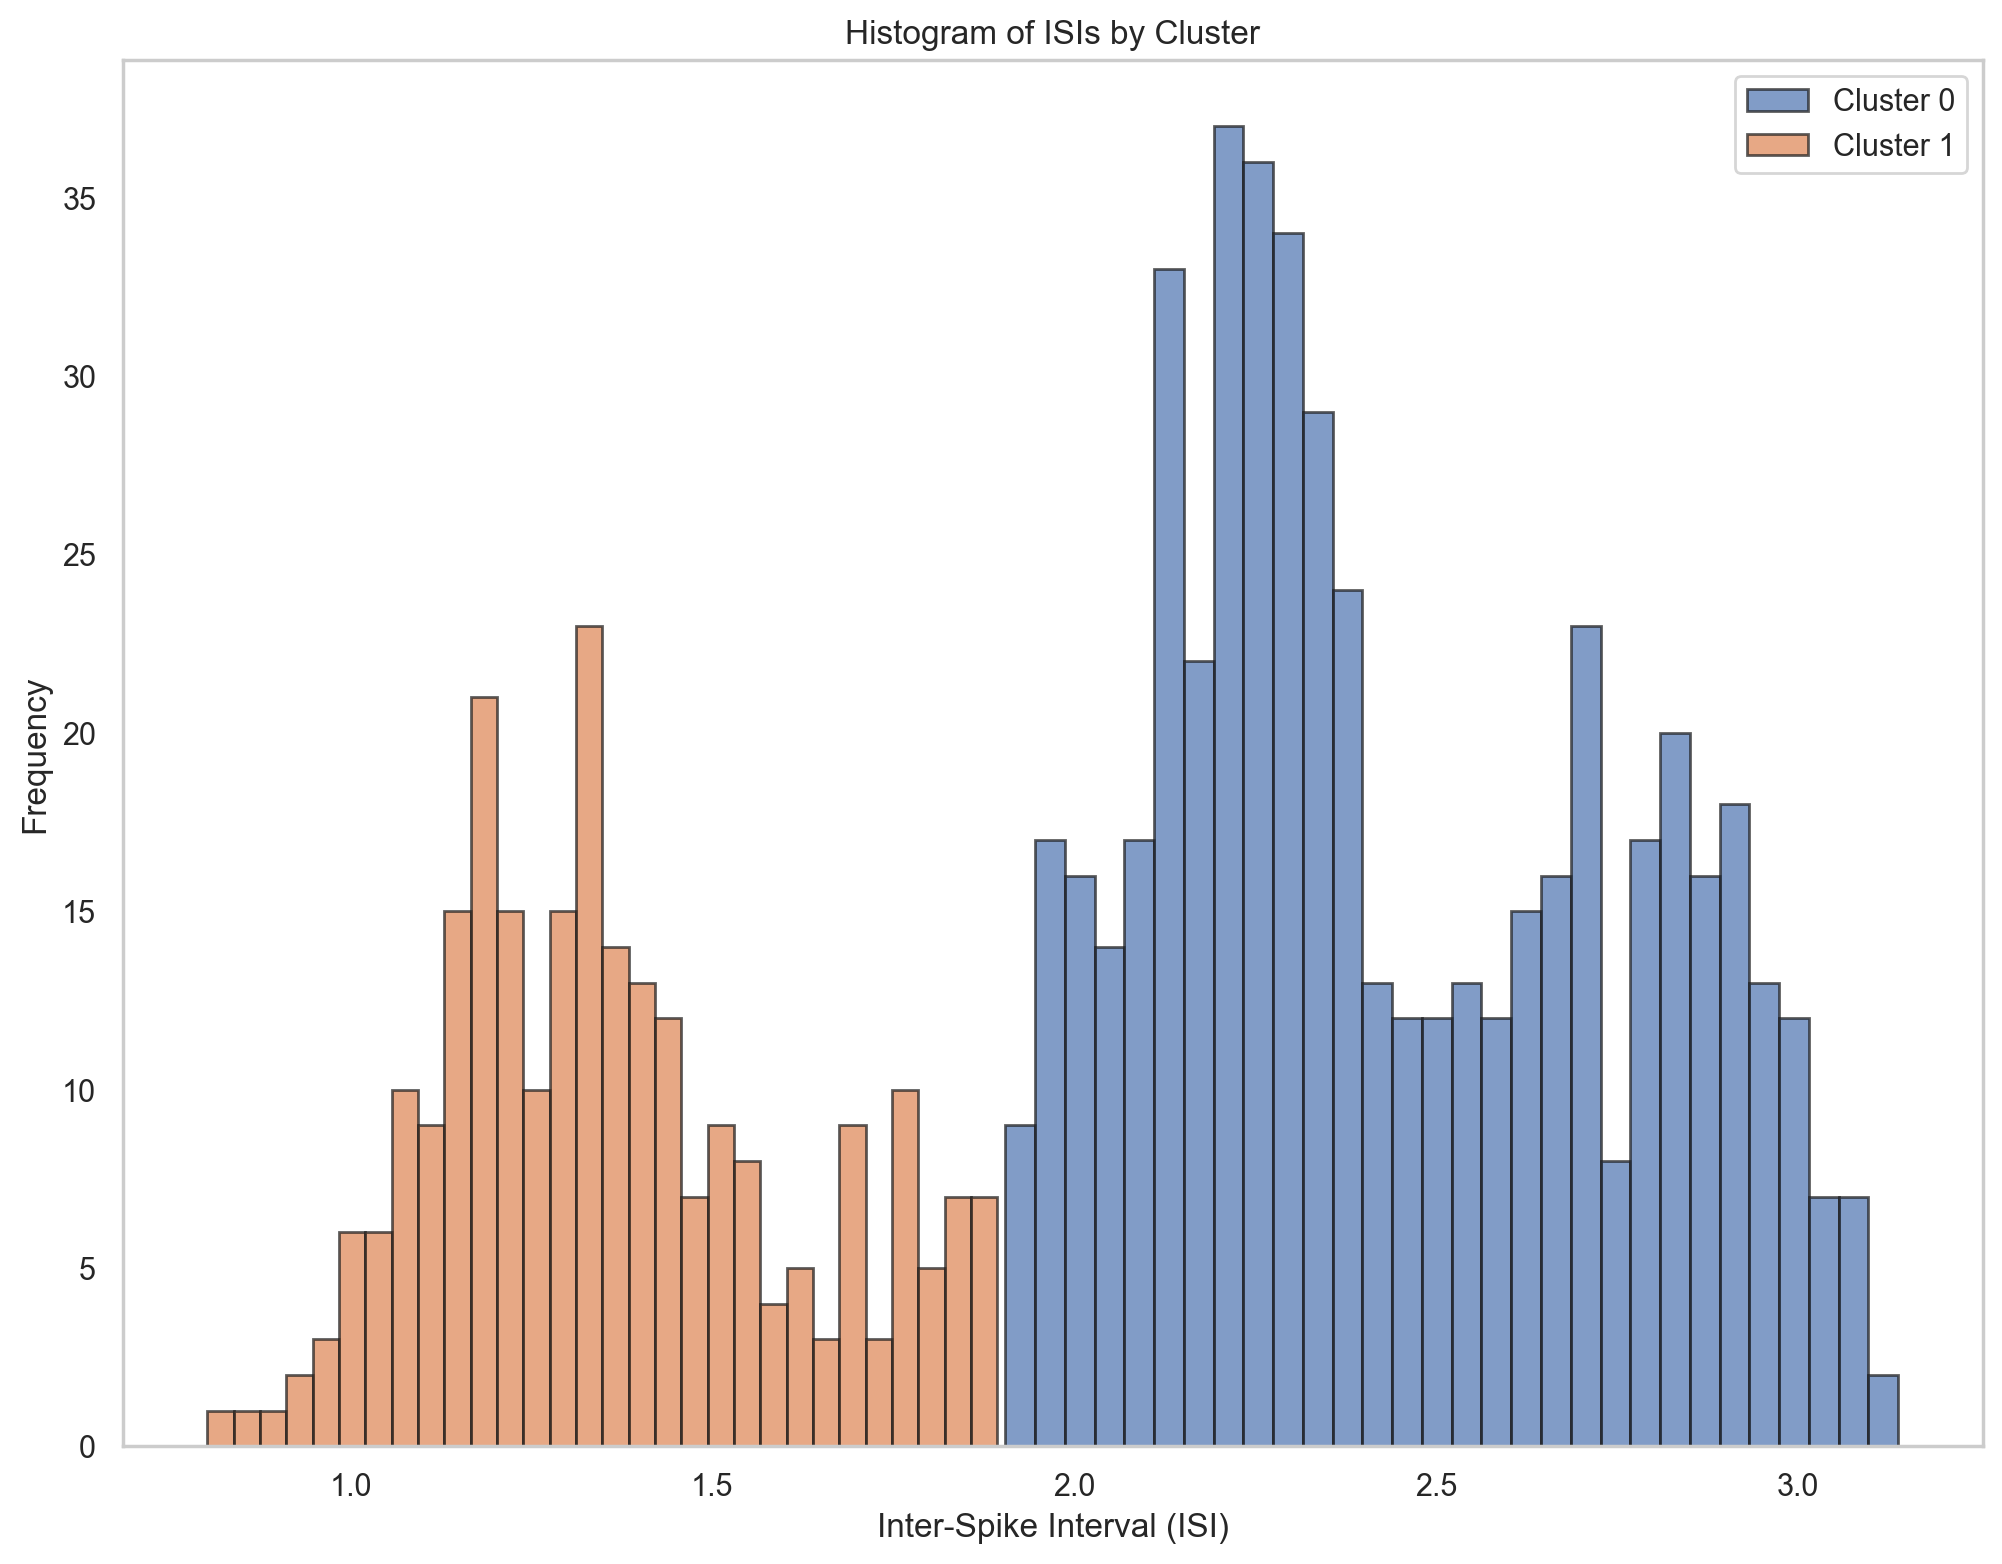

In [27]:
#split two clusters and then generate two different models?
isis = df_features['log_isi'].values
isis_reshaped = isis.reshape(-1, 1) 

# Perform MiniBatchKMeans clustering
mini_kmeans = MiniBatchKMeans(n_clusters=2, random_state=0, batch_size=100).fit(isis_reshaped)
clusters = mini_kmeans.labels_

# Visualize the clusters
plt.hist(isis[clusters == 0], bins=30, edgecolor='k', alpha=0.7, label='Cluster 0')
plt.hist(isis[clusters == 1], bins=30, edgecolor='k', alpha=0.7, label='Cluster 1')
plt.xlabel('Inter-Spike Interval (ISI)')
plt.ylabel('Frequency')
plt.title('Histogram of ISIs by Cluster')
plt.legend()
plt.show()

In [28]:
#separate features and target

features = df_features.drop(columns=['log_isi']).values
target = df_features['log_isi'].values

# Split features and target based on clusters
features_cluster_0 = features[clusters == 0]
target_cluster_0 = target[clusters == 0]
features_cluster_1 = features[clusters == 1]
target_cluster_1 = target[clusters == 1]

original_indices = df_features['original_index'].values
original_indices_cluster_0 = original_indices[clusters == 0]
original_indices_cluster_1 = original_indices[clusters == 1]

In [29]:
df_features

,ramp_amp,inflection_time,inflection_amp,peak_amp,peak_width,peak_sharpness,exp_lambda,exp_const,log_isi,original_index
318,6.617638,0.32,3.545076,269.574837,0.28,96.662193,0.000040,-10.382162,1.700842,318
1697,29.057479,0.32,50.612722,92.085568,0.40,3.005638,3.248175,-9.373703,2.375675,1697
1700,8.350387,0.40,16.711417,86.855120,0.48,7.861766,3.373602,-9.011525,2.413059,1700
2465,10.630144,0.48,2.735586,168.729683,0.48,37.796094,2.676317,-15.864374,2.939980,2465
2480,6.153397,0.40,11.486529,217.832421,0.36,50.064635,3.738365,-16.790187,2.345871,2480
...,...,...,...,...,...,...,...,...,...,...
9403,4.932805,0.42,-1.489863,217.677242,0.58,35.372947,2.628715,-7.034404,2.417198,9403
9404,7.265778,0.32,10.017293,260.922642,0.48,50.732213,4.779786,-22.521934,2.823645,9404
9406,12.318685,0.42,3.364254,238.938940,0.48,47.260429,2.703519,-21.088288,1.799271,9406
9410,-5.901455,0.62,-2.260811,183.943833,0.64,22.658891,2.090450,-12.384307,3.061328,9410


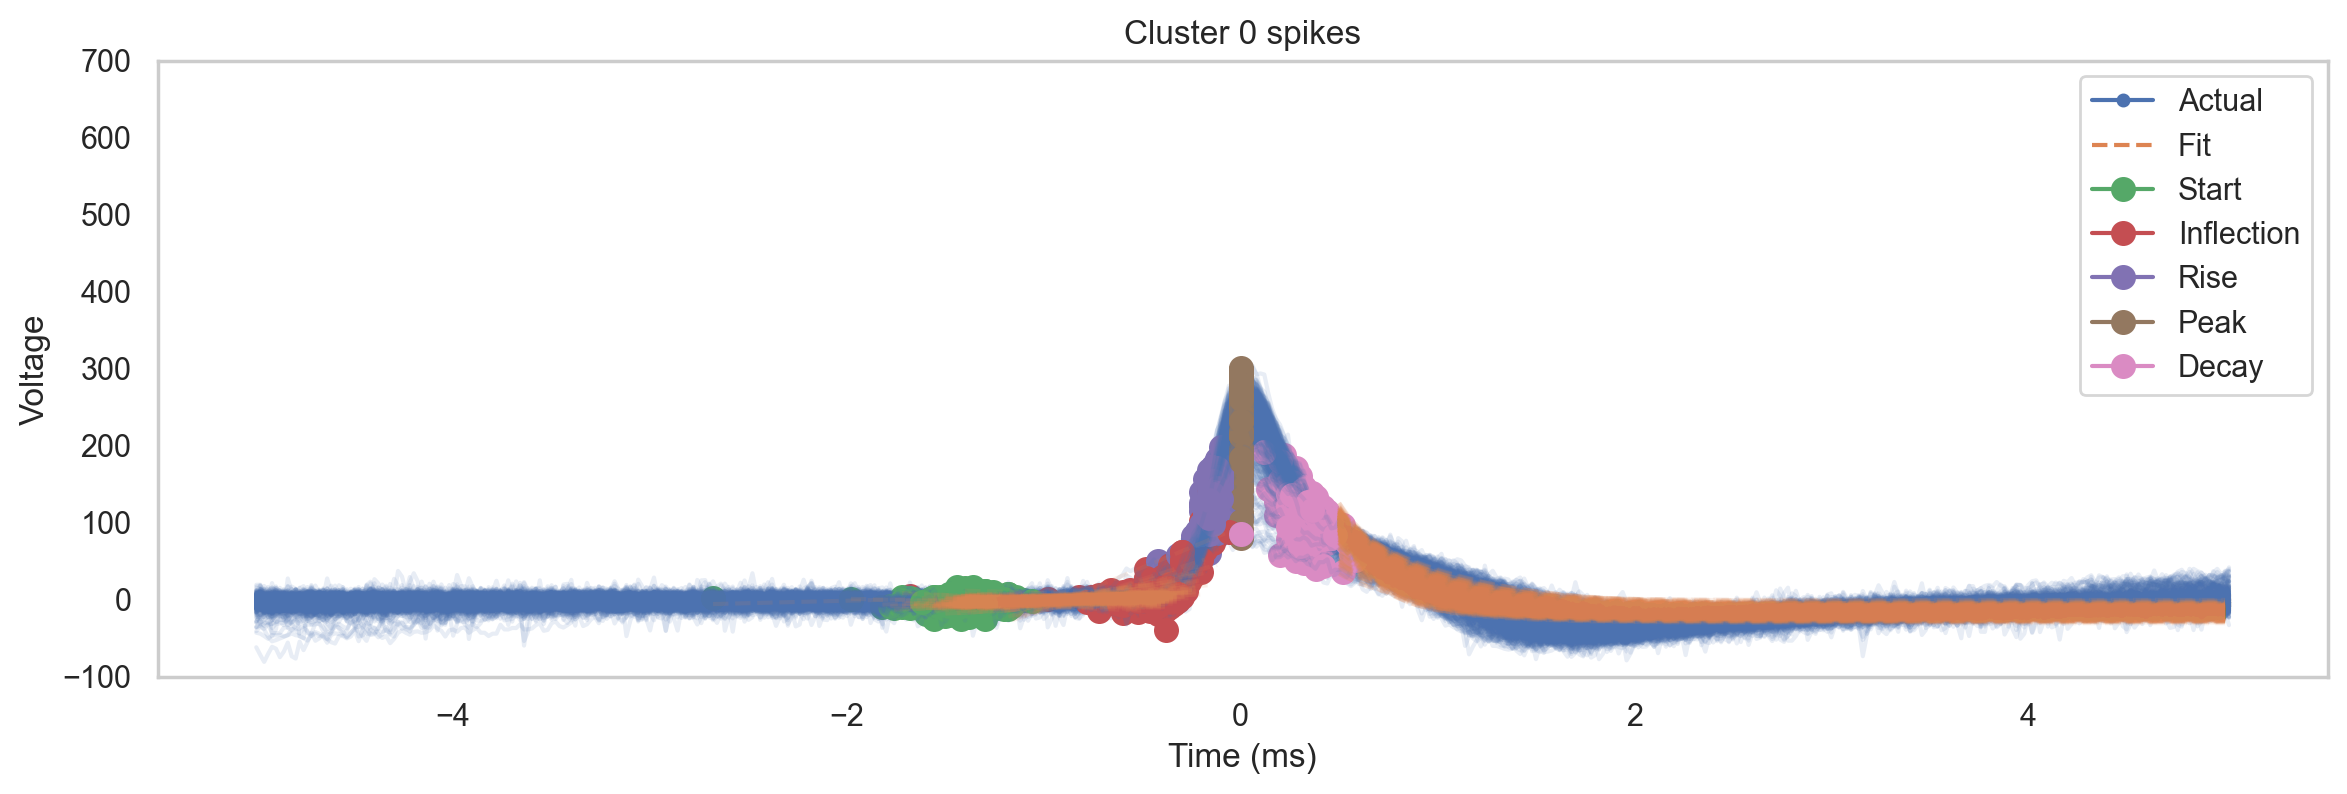

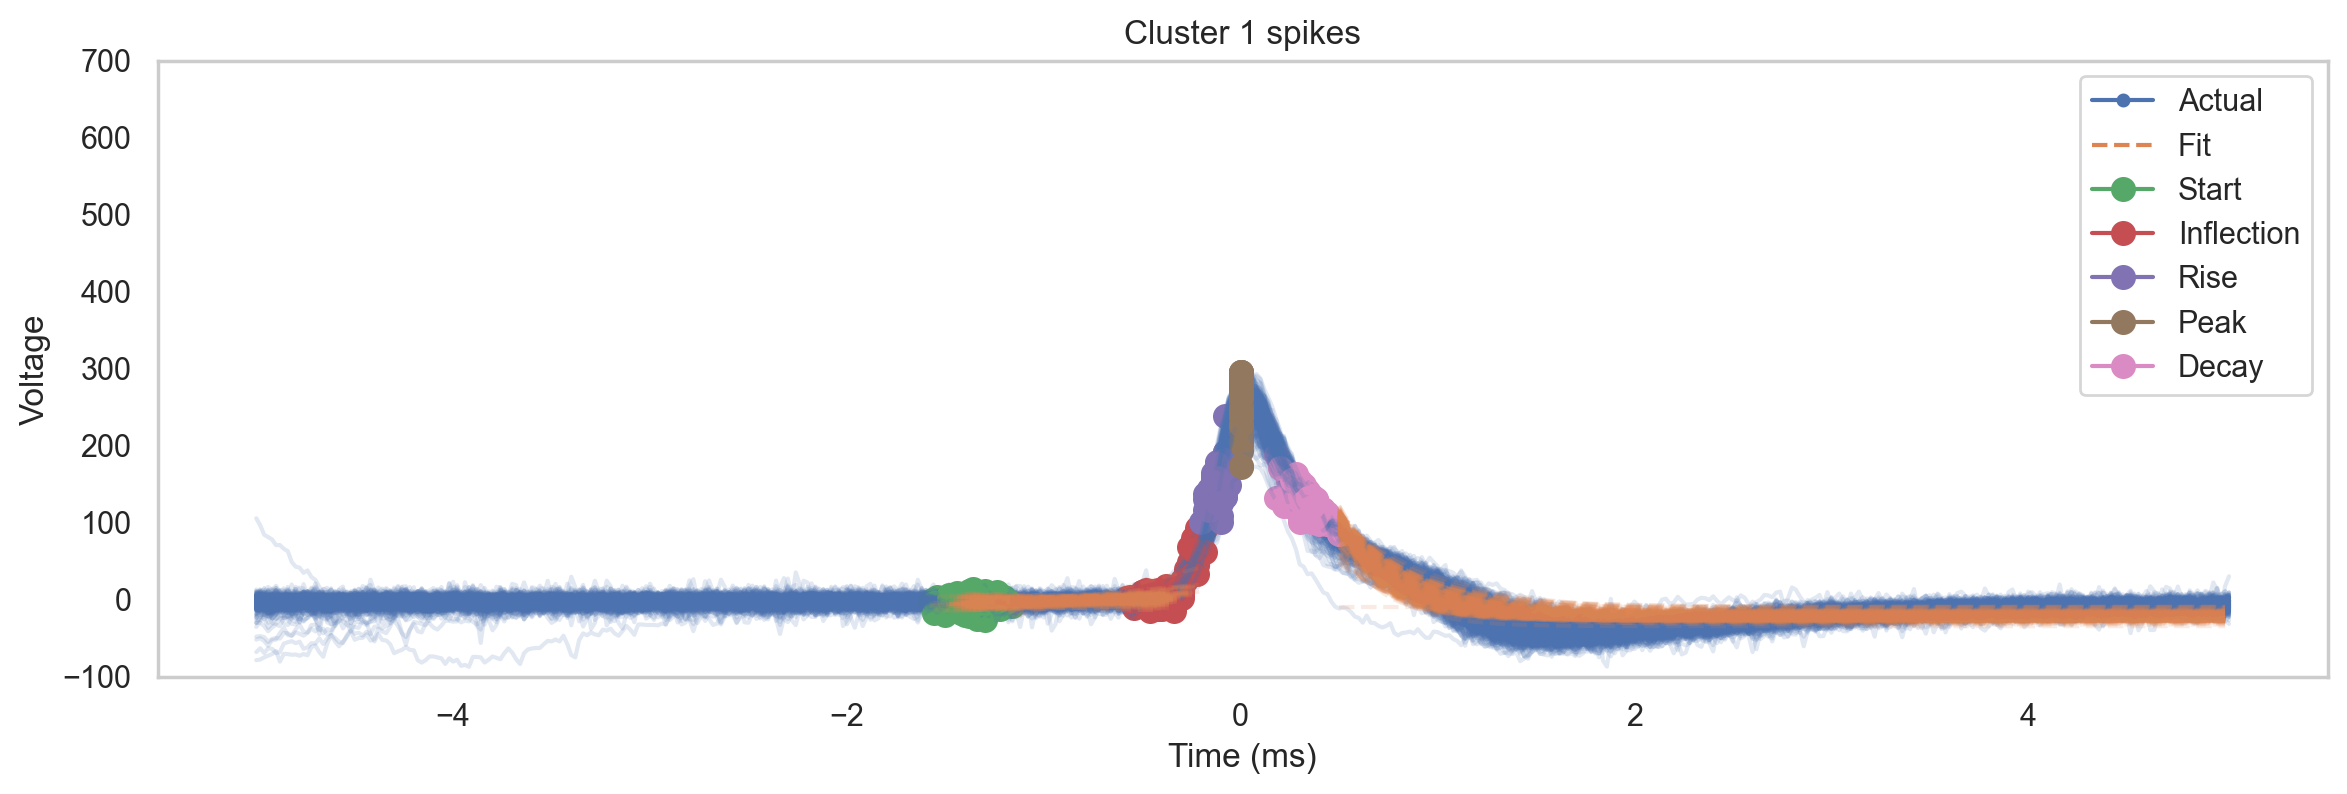

In [30]:
# Plot spikes for Cluster 0
sp.plot(inds=original_indices_cluster_0, mode='full', show_points=True)
plt.title("Cluster 0 spikes")
plt.ylim(-100,700)
plt.show()


# Plot spikes for Cluster 1
sp.plot(inds=original_indices_cluster_1, mode='full', show_points=True)
plt.title("Cluster 1 spikes")
plt.ylim(-100,700)
plt.show()

#### Troubleshooting cluster linear regressoin

In [31]:
# Standardize features
scaler_0 = StandardScaler()
features_cluster_0_scaled = scaler_0.fit_transform(features_cluster_0)

scaler_1 = StandardScaler()
features_cluster_1_scaled = scaler_1.fit_transform(features_cluster_1)

# Split data into training and test sets
X_train_0, X_test_0, y_train_0, y_test_0 = train_test_split(features_cluster_0_scaled, target_cluster_0, test_size=0.2, random_state=42)
X_train_1, X_test_1, y_train_1, y_test_1 = train_test_split(features_cluster_1_scaled, target_cluster_1, test_size=0.2, random_state=42)

# Function to train the model with progress tracking
def train_model_with_progress(X_train, y_train, max_iter=1000):
    model = Ridge(solver='saga', max_iter=1, random_state=42)
    progress_bar = tqdm(range(max_iter), desc="Training Ridge Regression")
    for _ in progress_bar:
        model.max_iter += 1
        model.fit(X_train, y_train)
    return model

# Train models with progress tracking
start_time = time.time()
model_0 = train_model_with_progress(X_train_0, y_train_0)
print("Training time for model_0:", time.time() - start_time)

start_time = time.time()
model_1 = train_model_with_progress(X_train_1, y_train_1)
print("Training time for model_1:", time.time() - start_time)

# Predict and calculate mean squared error
predictions_0 = model_0.predict(X_test_0)
mse_0 = mean_squared_error(y_test_0, predictions_0)
print(f'Mean Squared Error for Cluster 0: {mse_0}')

predictions_1 = model_1.predict(X_test_1)
mse_1 = mean_squared_error(y_test_1, predictions_1)
print(f'Mean Squared Error for Cluster 1: {mse_1}')


Training Ridge Regression:   0%|          | 0/1000 [00:00<?, ?it/s]

Training time for model_0: 1.1890711784362793


Training Ridge Regression:   0%|          | 0/1000 [00:00<?, ?it/s]

Training time for model_1: 1.1348369121551514
Mean Squared Error for Cluster 0: 0.10728174483068412
Mean Squared Error for Cluster 1: 0.06146406799928007


In [32]:
#rsq values
r2_0 = r2_score(y_test_0, predictions_0)
r2_1 = r2_score(y_test_1, predictions_1)

print(f'R-squared for Cluster 0: {r2_0}')

print(f'R-squared for Cluster 1: {r2_1}')

R-squared for Cluster 0: 0.004317456442178735
R-squared for Cluster 1: -0.0716756596432715


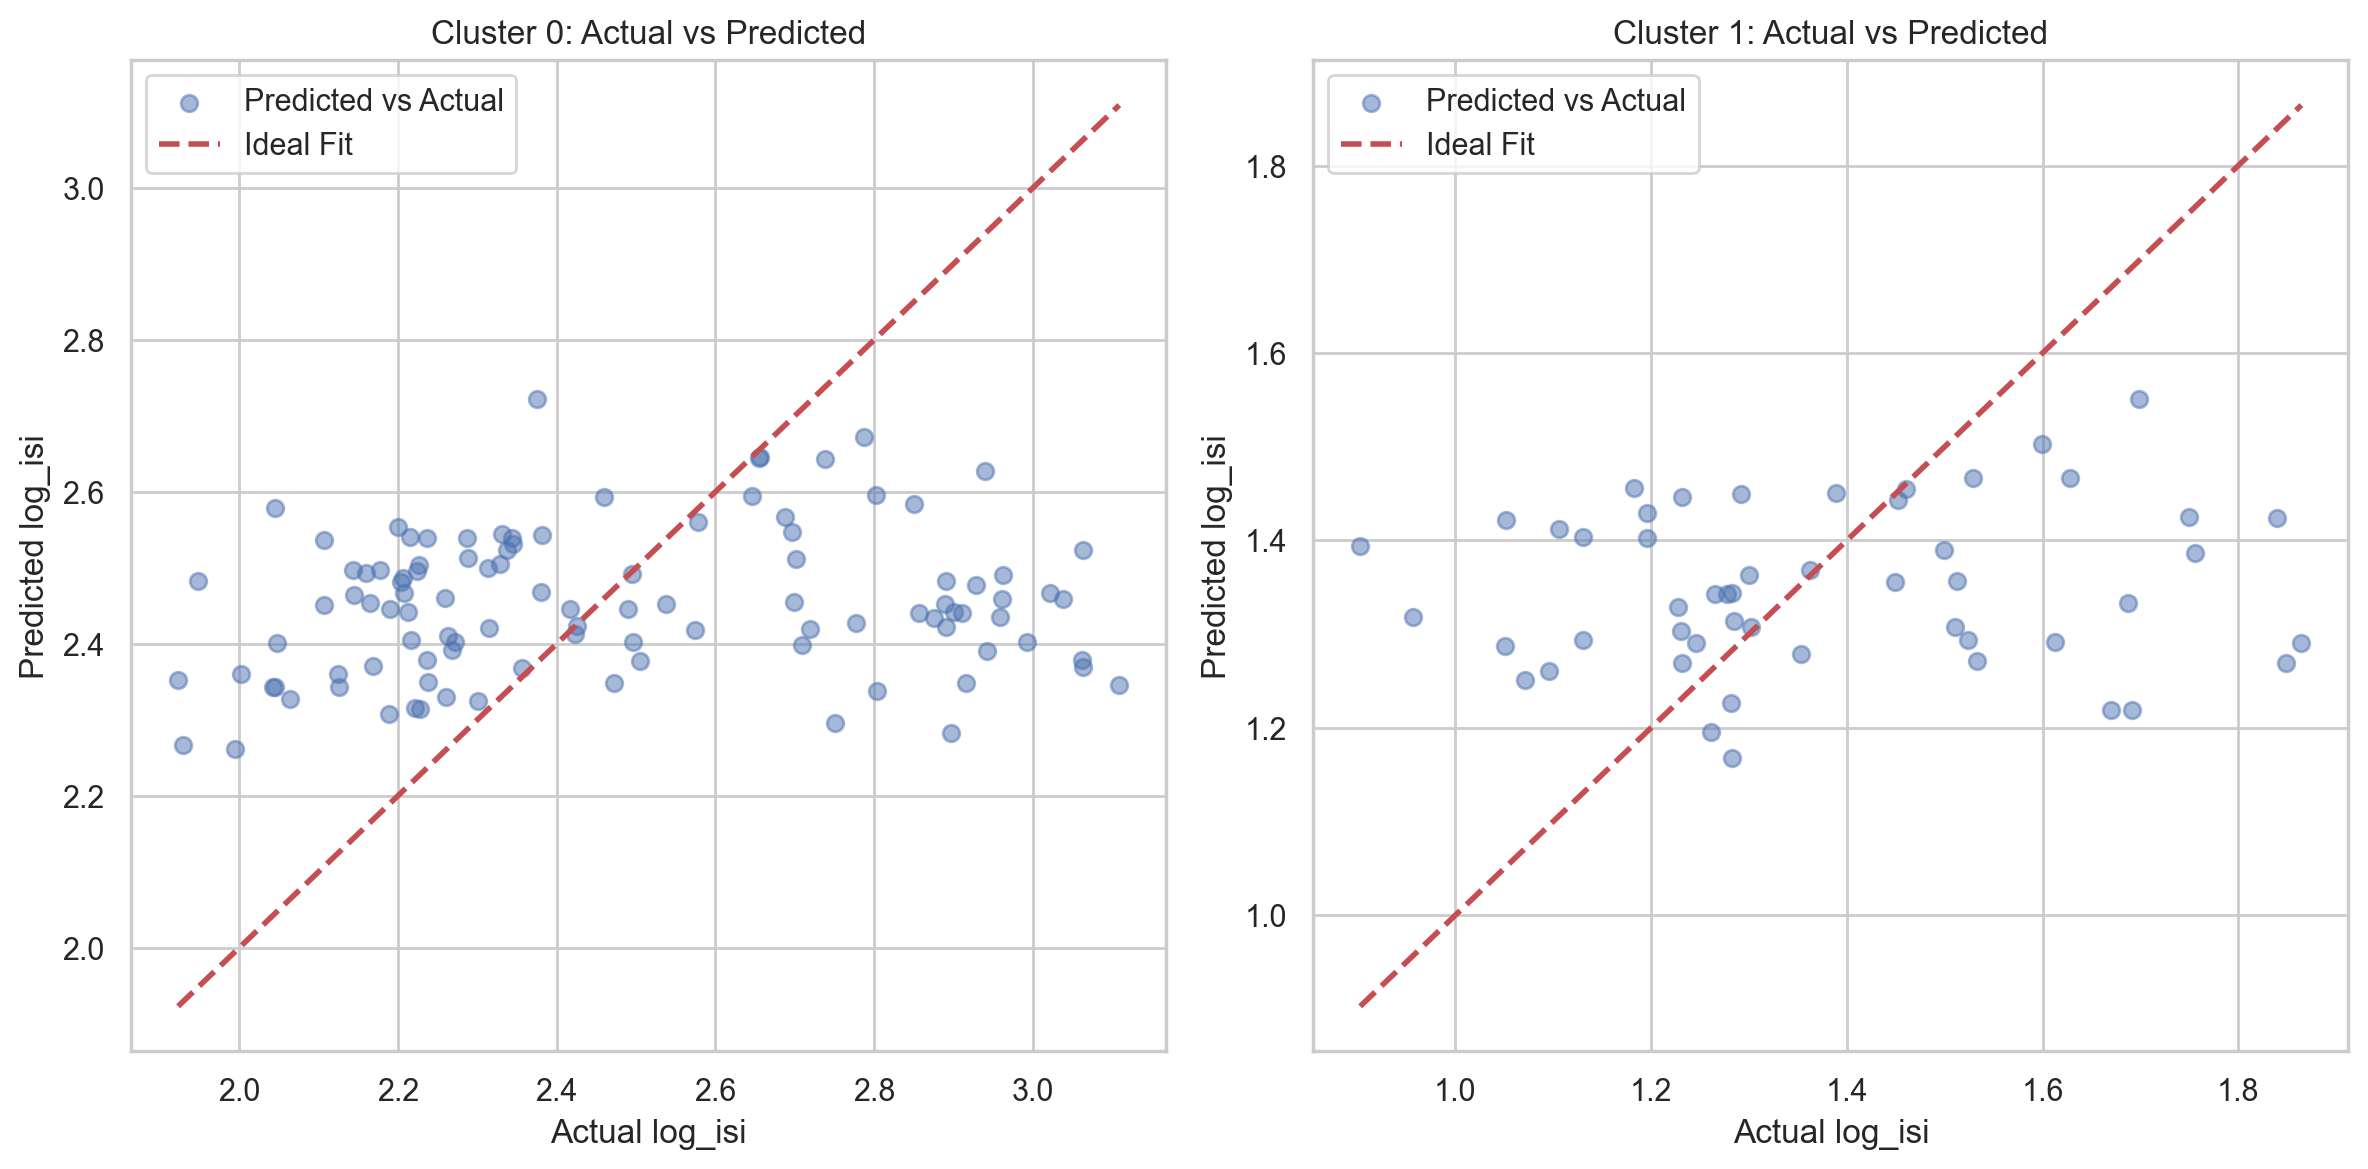

In [33]:
# Visualize the results

# Plotting actual vs predicted values for Cluster 0
plt.figure(figsize=(12, 19))

plt.subplot(1, 2, 1)
plt.scatter(y_test_0, predictions_0, alpha=0.5, label='Predicted vs Actual')
plt.plot([y_test_0.min(), y_test_0.max()], [y_test_0.min(), y_test_0.max()], 'r--', lw=2, label='Ideal Fit')
plt.xlabel('Actual log_isi')
plt.ylabel('Predicted log_isi')
plt.title('Cluster 0: Actual vs Predicted')
plt.legend()
plt.grid(True)

# Plotting actual vs predicted values for Cluster 1
plt.subplot(1, 2, 2)
plt.scatter(y_test_1, predictions_1, alpha=0.5, label='Predicted vs Actual')
plt.plot([y_test_1.min(), y_test_1.max()], [y_test_1.min(), y_test_1.max()], 'r--', lw=2, label='Ideal Fit')
plt.xlabel('Actual log_isi')
plt.ylabel('Predicted log_isi')
plt.title('Cluster 1: Actual vs Predicted')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

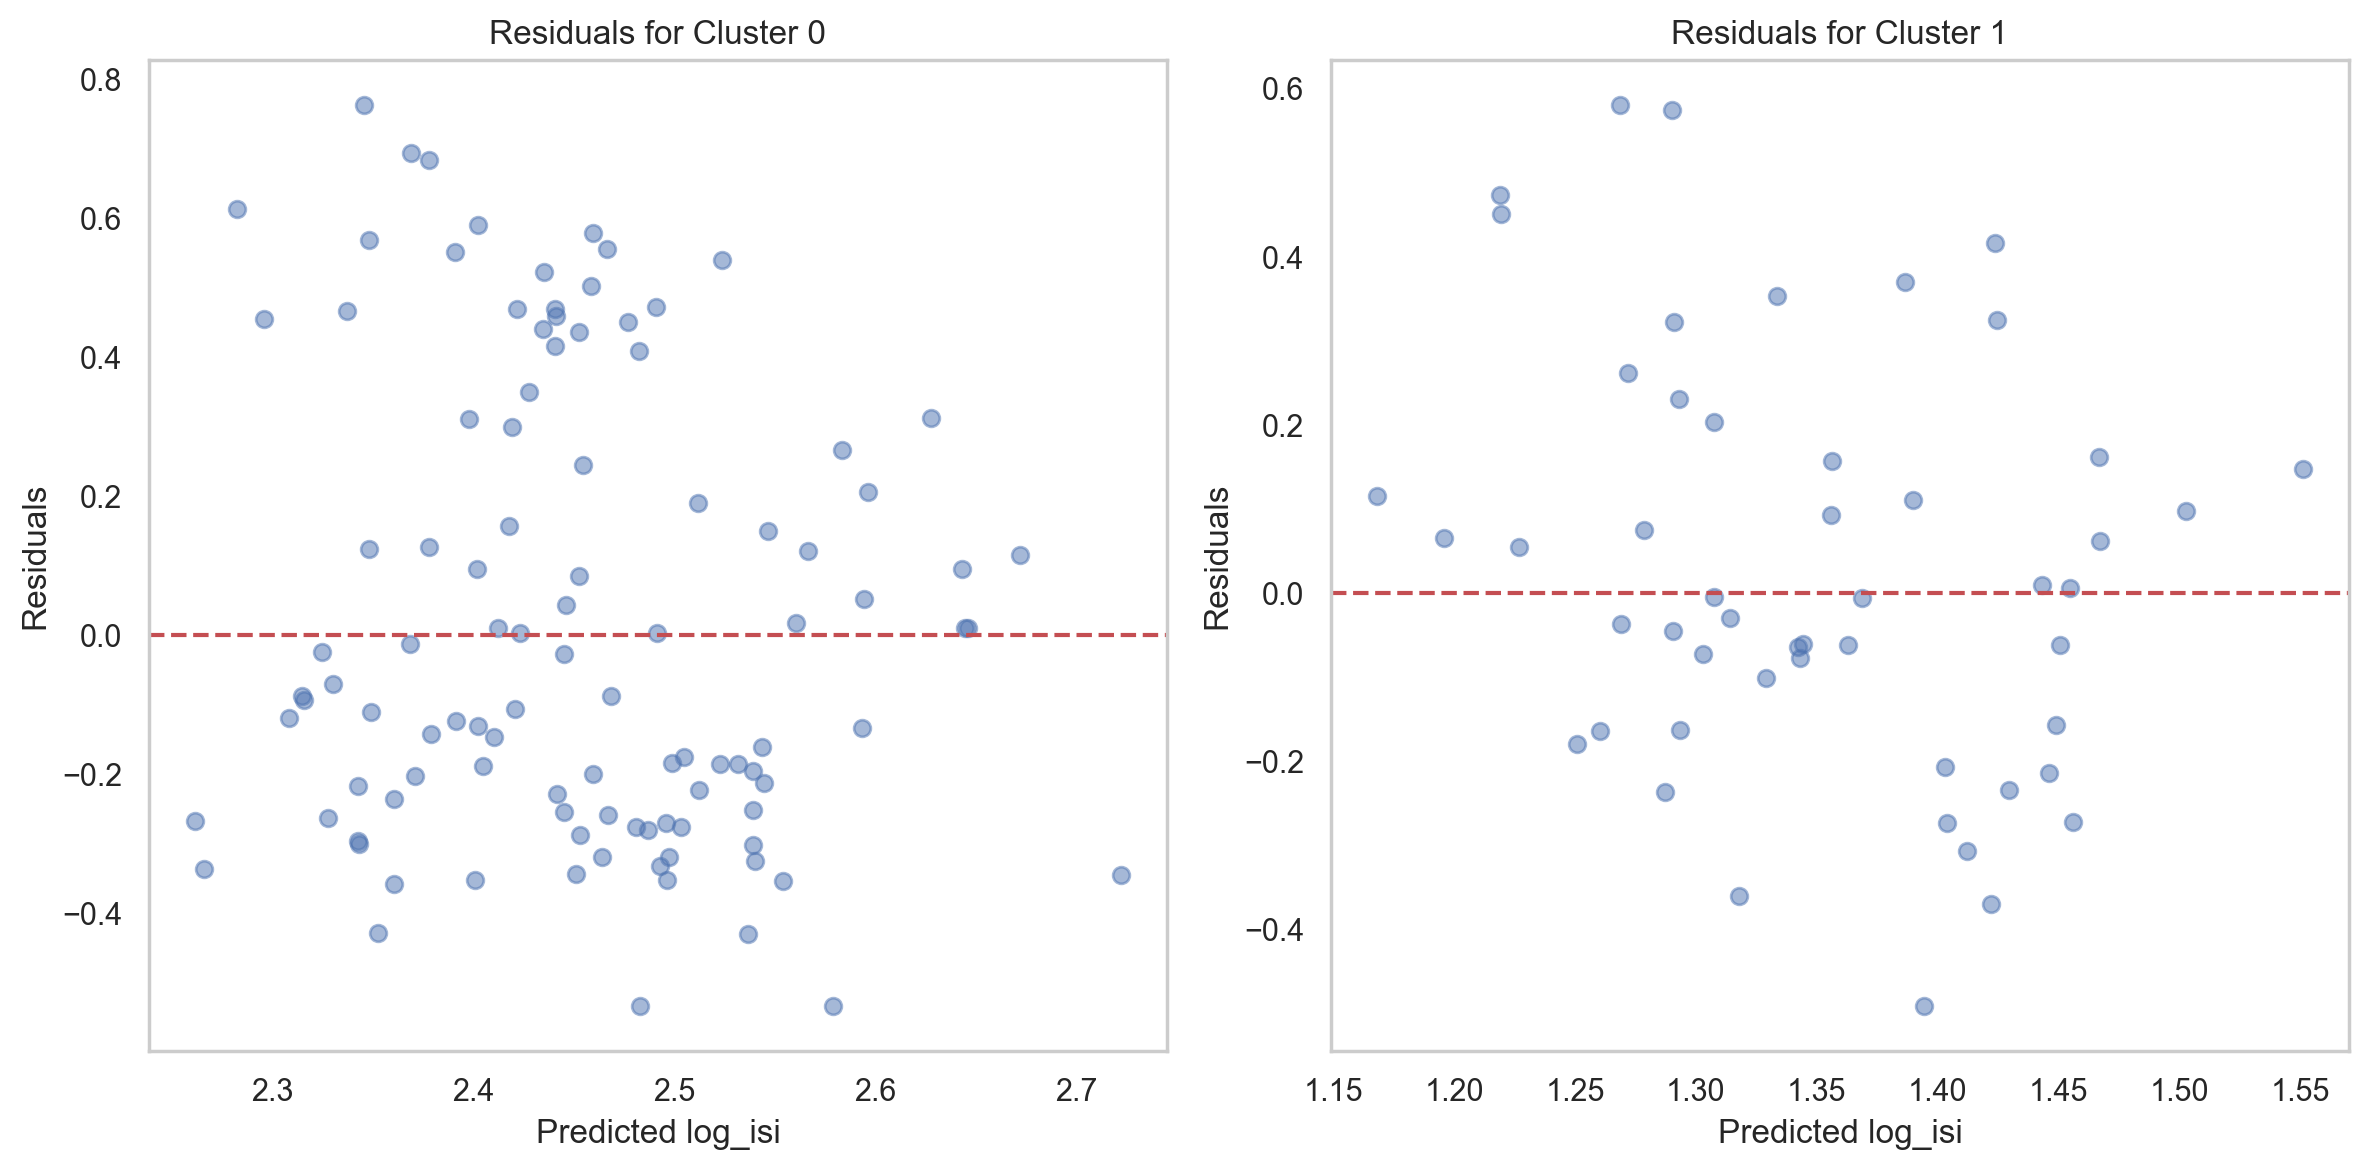

In [34]:
# Calculate residuals
residuals_0 = y_test_0 - predictions_0
residuals_1 = y_test_1 - predictions_1

# Plot residuals for Cluster 0
plt.figure(figsize=(12, 19))

plt.subplot(1, 2, 1)
plt.scatter(predictions_0, residuals_0, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted log_isi')
plt.ylabel('Residuals')
plt.title('Residuals for Cluster 0')

# Plot residuals for Cluster 1
plt.subplot(1, 2, 2)
plt.scatter(predictions_1, residuals_1, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted log_isi')
plt.ylabel('Residuals')
plt.title('Residuals for Cluster 1')

plt.tight_layout()
plt.show()

In [35]:
### Feature importance

num_features_0 = features_cluster_0.shape[1]
num_features_1 = features_cluster_1.shape[1]

features_0 = [f'Feature_{i}' for i in range(num_features_0)]
features_1 = [f'Feature_{i}' for i in range(num_features_1)]

# Extract coefficients from the trained models
coefficients_0 = model_0.coef_
coefficients_1 = model_1.coef_

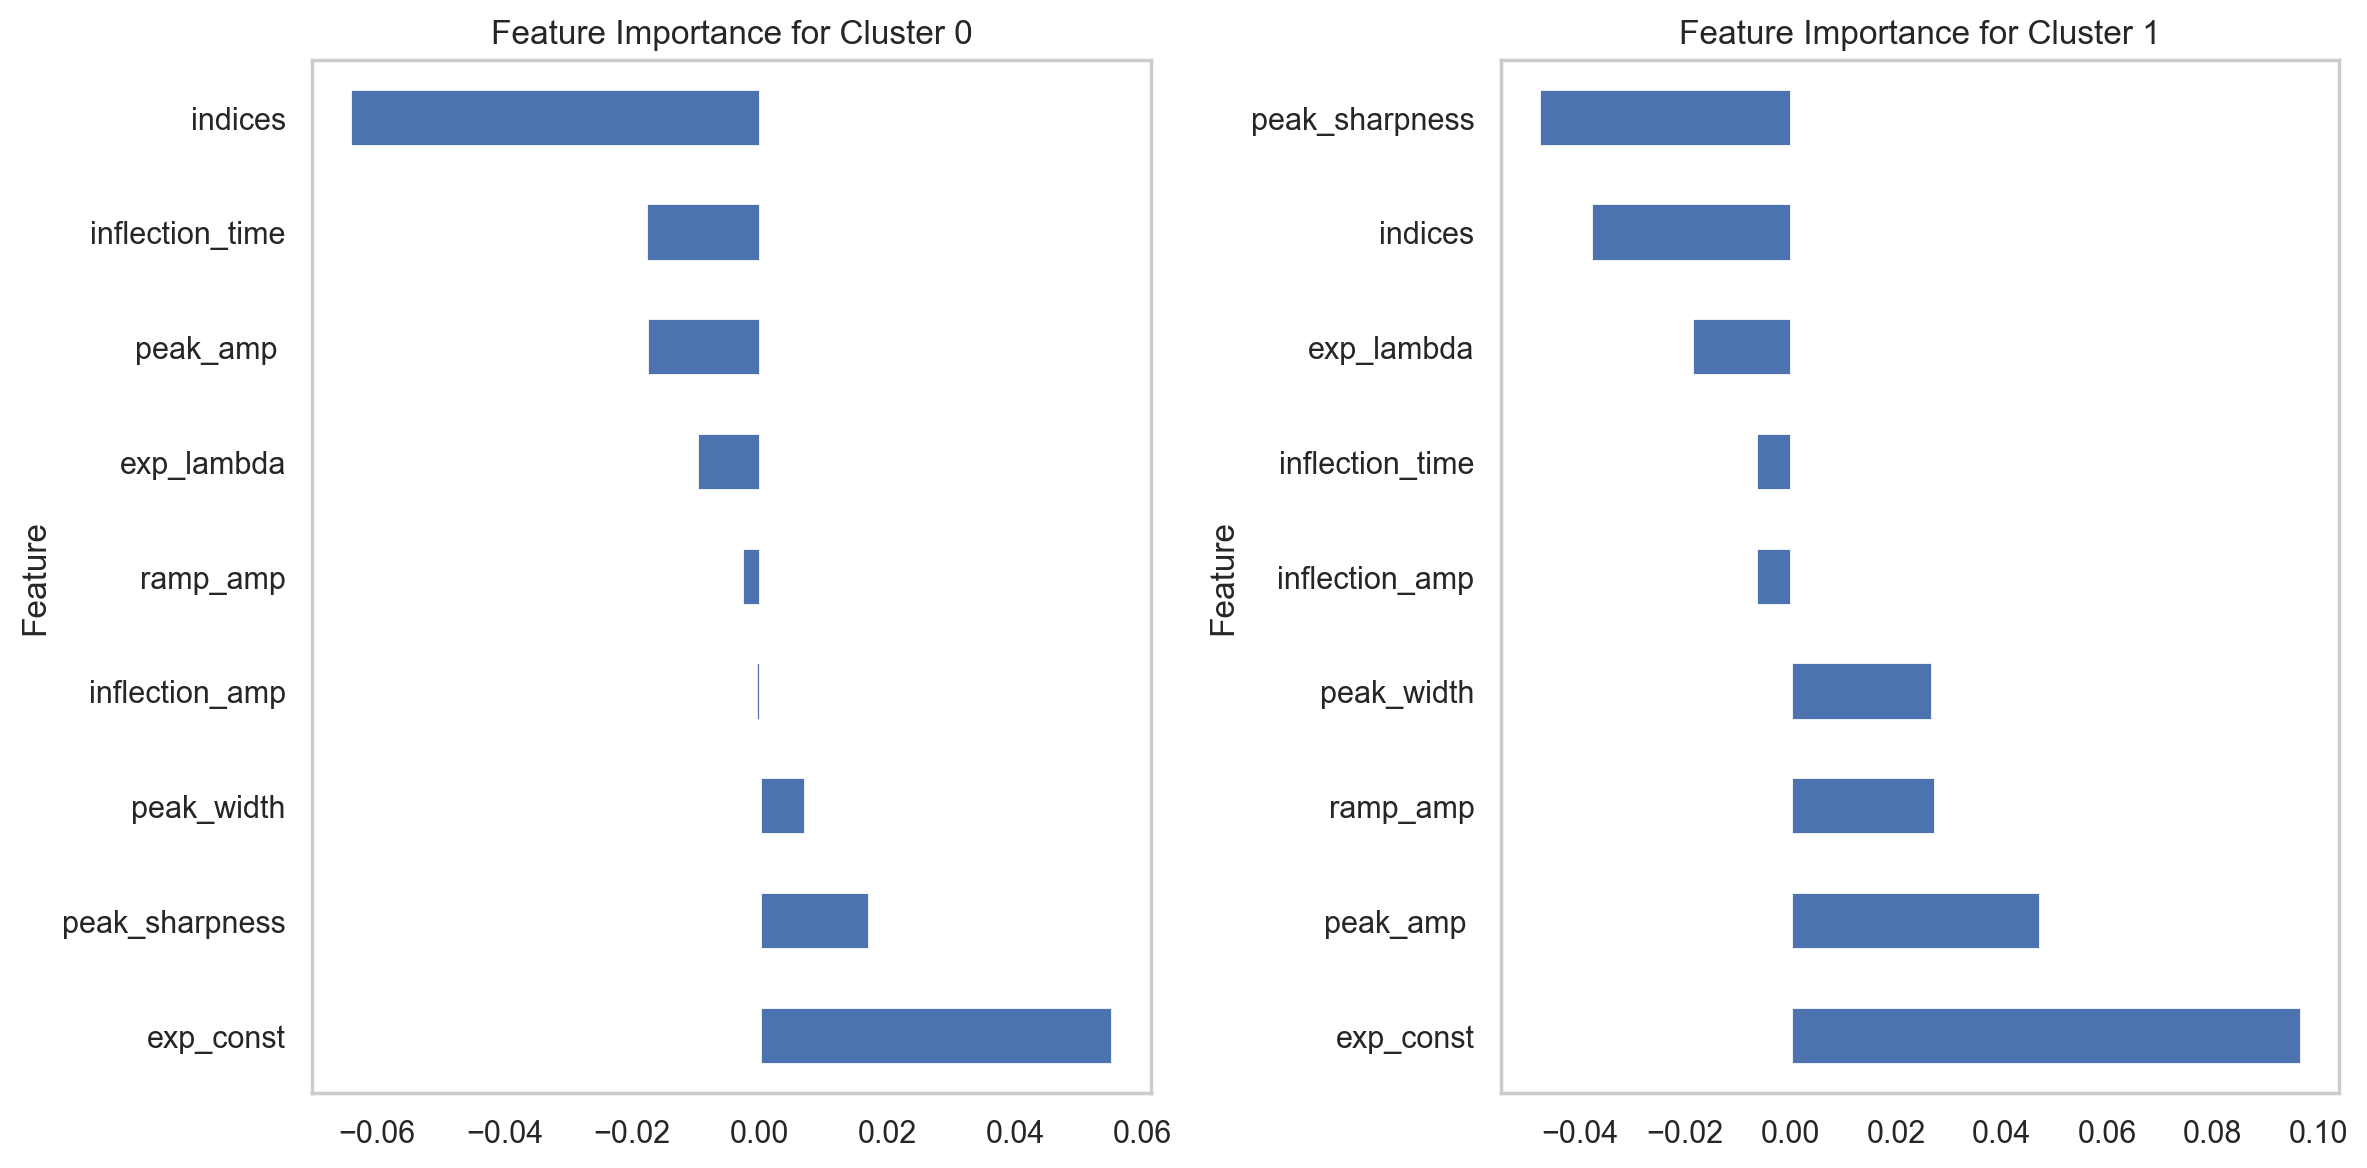

In [36]:
# Assuming you have the actual feature names
actual_feature_names = ['ramp_amp', 'inflection_time', 	'inflection_amp', 	'peak_amp ',	'peak_width', 	'peak_sharpness', 	'exp_lambda', 	'exp_const', 'indices']  # replace with your actual feature names


# Create DataFrames for feature importance
feature_importance_0 = pd.DataFrame({
    'Feature': actual_feature_names,
    'Importance': coefficients_0
})

feature_importance_1 = pd.DataFrame({
    'Feature': actual_feature_names,
    'Importance': coefficients_1
})

# Plot feature importance for Cluster 0
plt.figure(figsize=(12, 19))

plt.subplot(1, 2, 1)
feature_importance_0.sort_values(by='Importance', ascending=False).plot.barh(x='Feature', y='Importance', ax=plt.gca(), legend=False)
plt.title('Feature Importance for Cluster 0')

# Plot feature importance for Cluster 1
plt.subplot(1, 2, 2)
feature_importance_1.sort_values(by='Importance', ascending=False).plot.barh(x='Feature', y='Importance', ax=plt.gca(), legend=False)
plt.title('Feature Importance for Cluster 1')

plt.tight_layout()
plt.show()


### Run regression without splitting into clusters 

In [37]:
# Standardize features
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(features_scaled, target, test_size=0.2, random_state=42)


In [38]:
# Train model with progress tracking
start_time = time.time()
model = train_model_with_progress(X_train, y_train)
print("Training time for the model:", time.time() - start_time)

# Predict and calculate mean squared error and R-squared
predictions_all = model.predict(X_test)
mse_all= mean_squared_error(y_test, predictions_all)
r2_all = r2_score(y_test, predictions_all)
print(f'Mean Squared Error: {mse_all}')
print(f'R-squared: {r2_all}')

Training Ridge Regression:   0%|          | 0/1000 [00:00<?, ?it/s]

Training time for the model: 1.5743751525878906
Mean Squared Error: 0.23027202883382614
R-squared: 0.30613459880790705


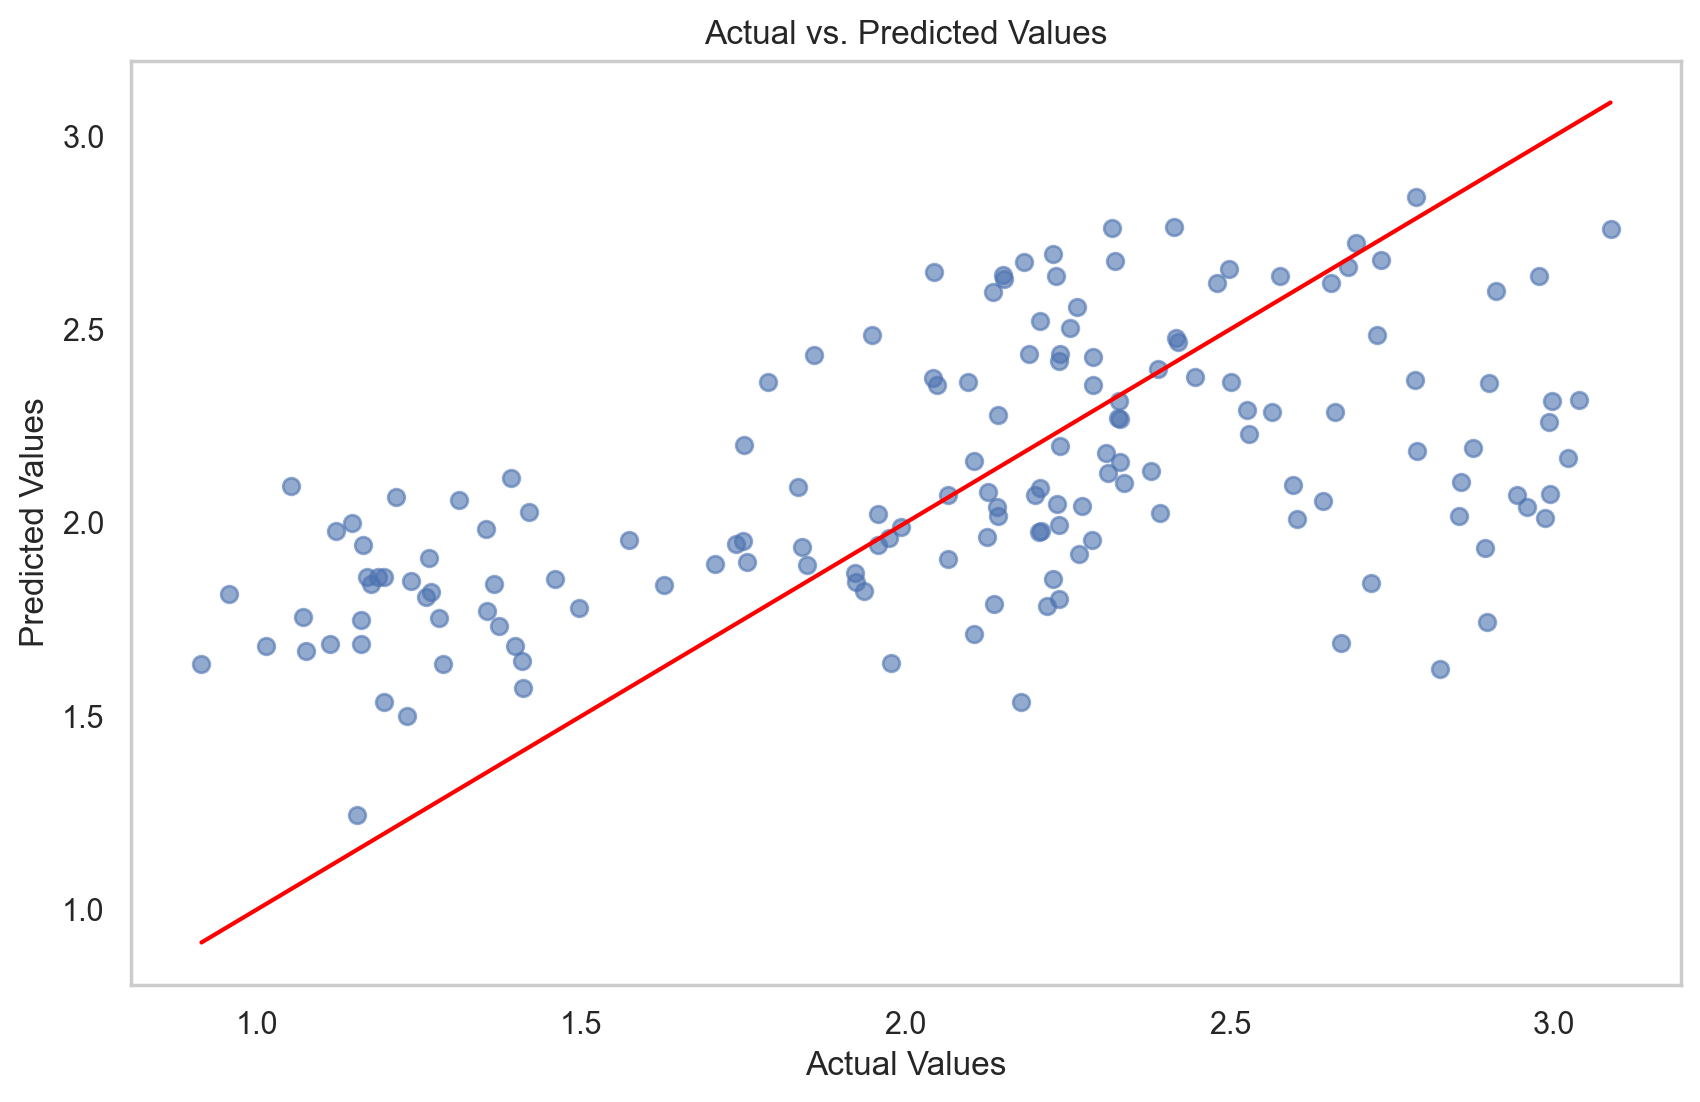

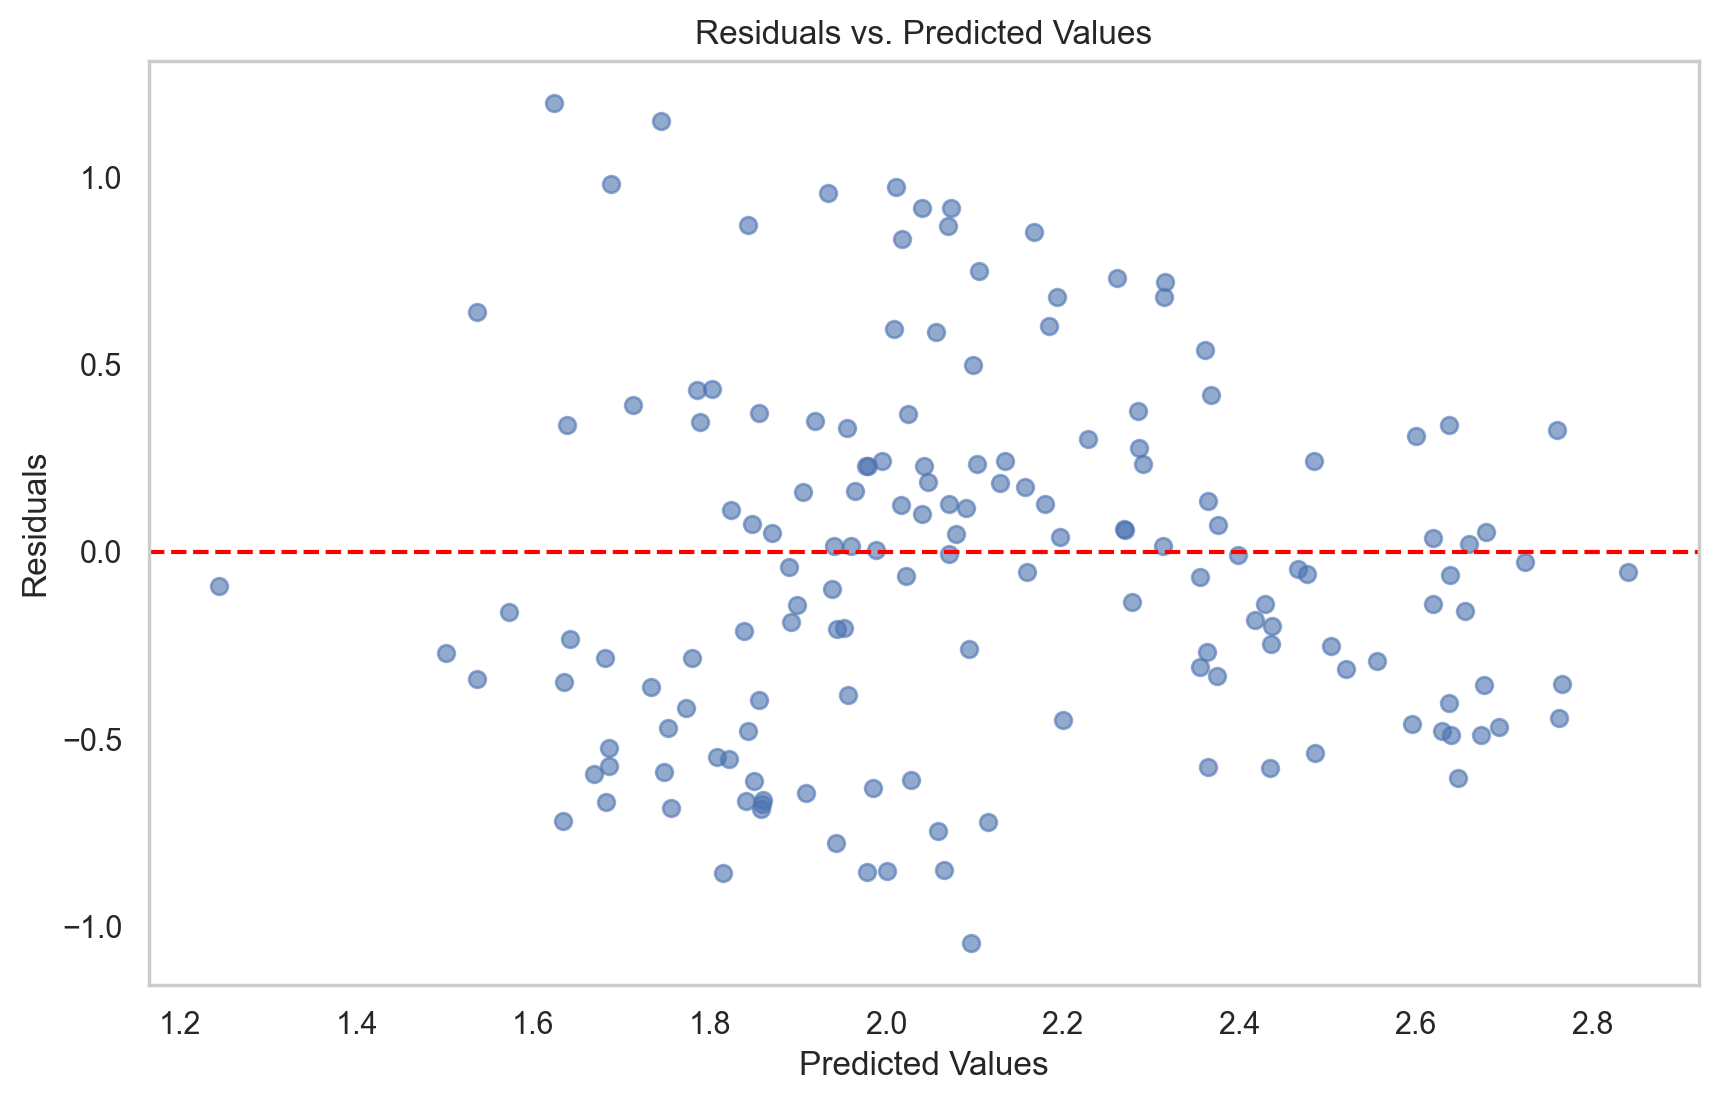

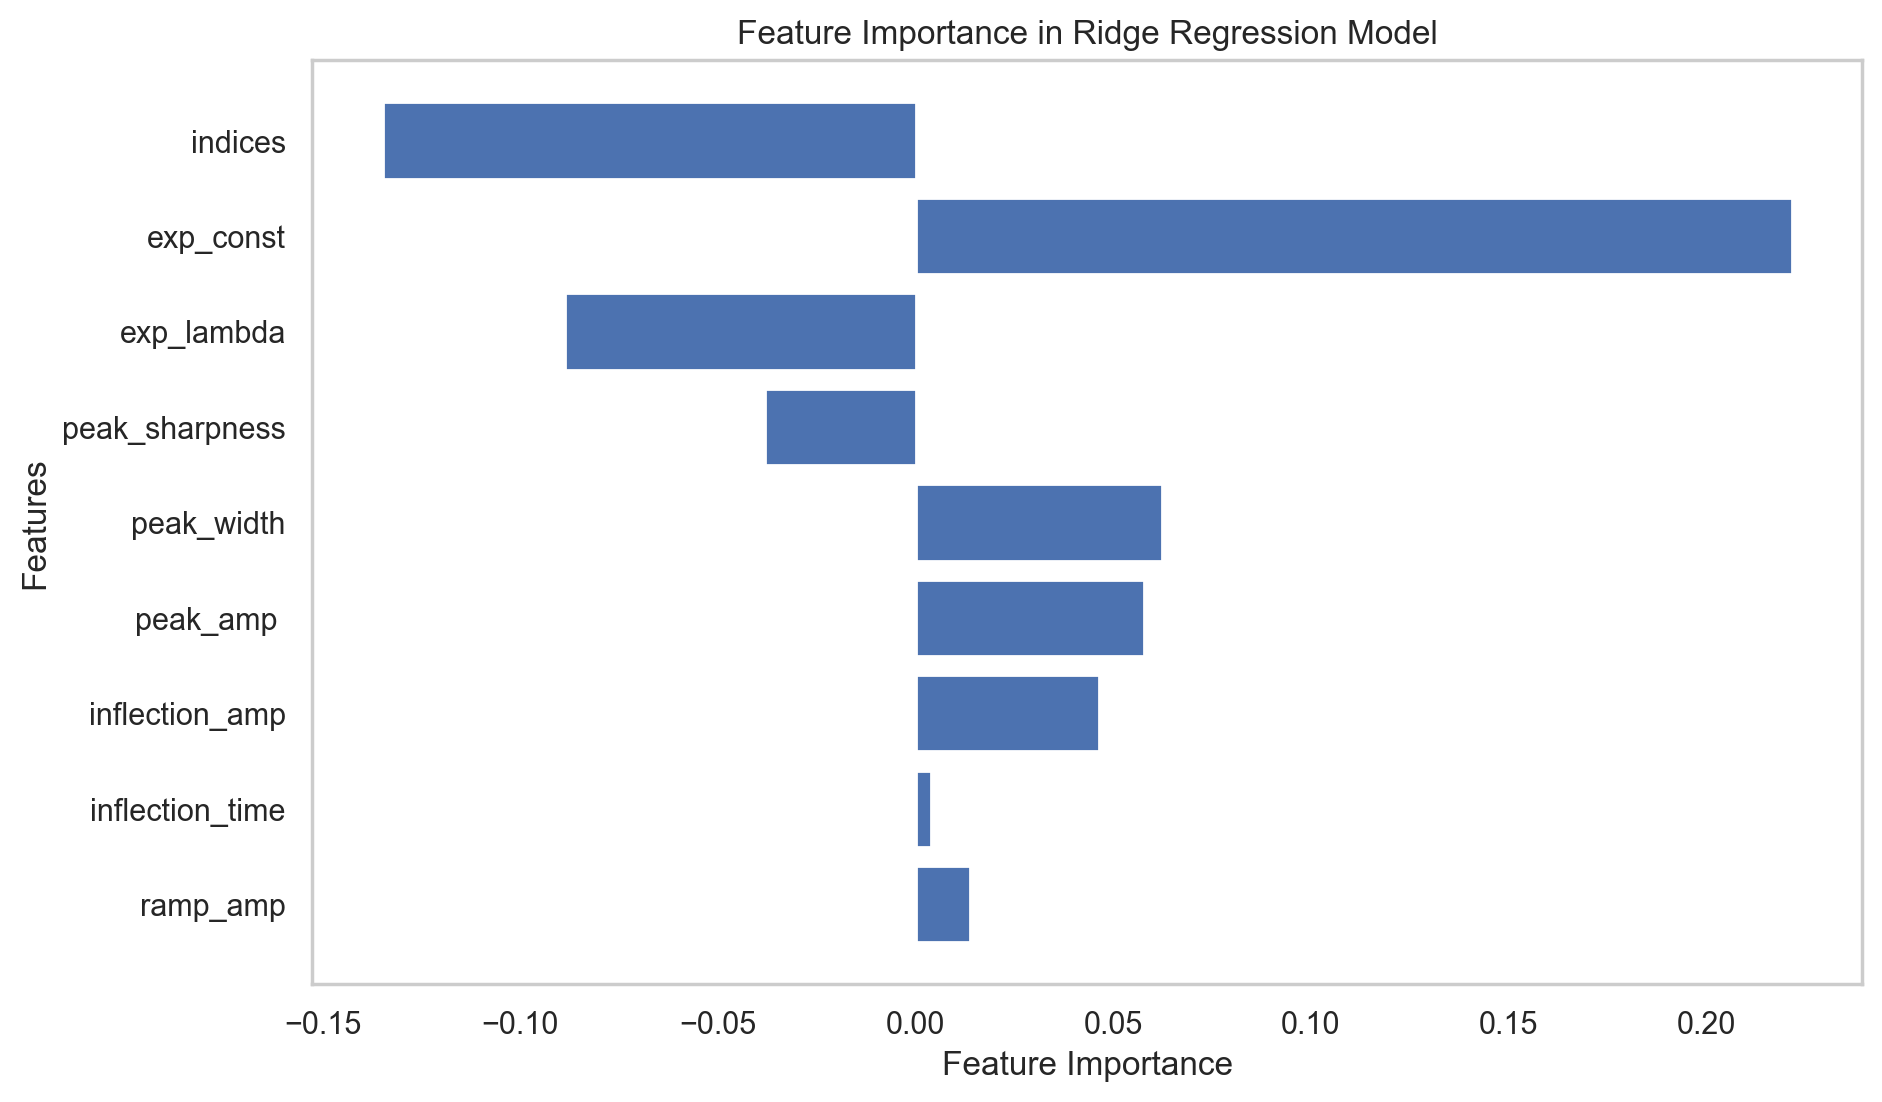

In [39]:
# Visualization of predictions
plt.figure(figsize=(10, 19))
plt.scatter(y_test, predictions_all, alpha=0.19)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red')  # 45-degree line
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted Values')
plt.show()

# Visualization of residuals
residuals = y_test - predictions_all
plt.figure(figsize=(10, 19))
plt.scatter(predictions_all, residuals, alpha=0.19)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs. Predicted Values')
plt.show()

# Feature importance
feature_importance = model.coef_

actual_feature_names = ['ramp_amp', 'inflection_time', 	'inflection_amp', 	'peak_amp ',	'peak_width', 	'peak_sharpness', 	'exp_lambda', 	'exp_const', 'indices']  # replace with your actual feature names

plt.figure(figsize=(10, 19))
plt.barh(np.arange(len(feature_importance)), feature_importance)
plt.yticks(np.arange(len(feature_importance)), actual_feature_names )  # Replace with actual feature names
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title('Feature Importance in Ridge Regression Model')
plt.show()


### Compare models - not significantly diff based on MSE values, but differences (no stats) in rsq for the models 

In [40]:
# Predictions and metrics for Cluster 0
predictions_0 = model_0.predict(X_test_0)
mse_0 = mean_squared_error(y_test_0, predictions_0)
r2_0 = r2_score(y_test_0, predictions_0)

# Predictions and metrics for Cluster 1
predictions_1 = model_1.predict(X_test_1)
mse_1 = mean_squared_error(y_test_1, predictions_1)
r2_1 = r2_score(y_test_1, predictions_1)

# Predictions and metrics for the entire dataset
predictions_all = model.predict(X_test)
mse_all = mean_squared_error(y_test, predictions_all)
r2_all = r2_score(y_test, predictions_all)

print(f'MSE for Cluster 0: {mse_0}')
print(f'R² for Cluster 0: {r2_0}')
print(f'MSE for Cluster 1: {mse_1}')
print(f'R² for Cluster 1: {r2_1}')
print(f'MSE for Entire dataset: {mse_all}')
print(f'R² for Entire dataset: {r2_all}')

MSE for Cluster 0: 0.10728174483068412
R² for Cluster 0: 0.004317456442178735
MSE for Cluster 1: 0.06146406799928007
R² for Cluster 1: -0.0716756596432715
MSE for Entire dataset: 0.23027202883382614
R² for Entire dataset: 0.30613459880790705


In [41]:
# Calculate individual prediction errors
errors_0 = y_test_0 - predictions_0
errors_1 = y_test_1 - predictions_1
errors_all = y_test - predictions_all

In [42]:
from scipy.stats import f_oneway

# Perform ANOVA using the prediction errors
F_mse, p_value_mse = f_oneway(errors_0, errors_1, errors_all)

print(f'ANOVA results for MSE: F-statistic = {F_mse}, p-value = {p_value_mse}')



ANOVA results for MSE: F-statistic = 0.8728777161257693, p-value = 0.4187751164278226


In [43]:
from scipy.stats import ttest_ind

# T-tests for MSEs
t_mse_0_1, p_mse_0_1 = ttest_ind(errors_0, errors_1)
t_mse_0_all, p_mse_0_all = ttest_ind(errors_0, errors_all)
t_mse_1_all, p_mse_1_all = ttest_ind(errors_1, errors_all)

print(f'T-test results for MSE between Cluster 0 and Cluster 1: t-statistic = {t_mse_0_1}, p-value = {p_mse_0_1}')
print(f'T-test results for MSE between Cluster 0 and entire dataset: t-statistic = {t_mse_0_all}, p-value = {p_mse_0_all}')
print(f'T-test results for MSE between Cluster 1 and entire dataset: t-statistic = {t_mse_1_all}, p-value = {p_mse_1_all}')


T-test results for MSE between Cluster 0 and Cluster 1: t-statistic = -0.17940890412065405, p-value = 0.8578524757088707
T-test results for MSE between Cluster 0 and entire dataset: t-statistic = 1.0574851626748258, p-value = 0.291275531643045
T-test results for MSE between Cluster 1 and entire dataset: t-statistic = 0.9428283398791779, p-value = 0.34687849426592343


### Are the spikes in the cluster with shorter ISIs burst spikes?

Mean ISI for Cluster 0: 2.439255838524582
Mean ISI for Cluster 1: 1.3644669411116888
Cluster with shorter ISIs: 1
Indices of spikes with shorter ISIs: [ 318 2642 2686 2794 3332 3369 3461 3912 4014 4039 4074 4103 4107 4203
 4221 4235 4354 4629 4632 4666 4715 4734 4740 4743 4780 4843 4871 4911
 5014 5256 5383 5389 5410 5414 5419 5423 5462 5491 5524 5573 5621 5642
 5646 5649 5662 5676 5682 5714 5727 5749 5752 5755 5809 5826 5836 5845
 5901 5934 5993 6065 6206 6209 6215 6238 6244 6248 6285 6333 6337 6374
 6400 6416 6461 6464 6467 6477 6508 6544 6611 6640 6644 6664 6680 6686
 6687 6692 6715 6795 6828 6829 6833 6841 6849 6855 6886 6906 6912 6918
 6924 6929 6932 6933 6955 7014 7086 7107 7120 7140 7149 7239 7247 7267
 7279 7283 7284 7288 7308 7331 7335 7339 7351 7364 7369 7372 7394 7401
 7419 7429 7459 7515 7551 7560 7564 7567 7606 7634 7656 7659 7673 7682
 7690 7700 7708 7713 7731 7749 7777 7785 7789 7814 7917 7923 7953 7964
 7965 7966 7969 7976 7979 8027 8064 8122 8158 8228 8244 8256 8290 83

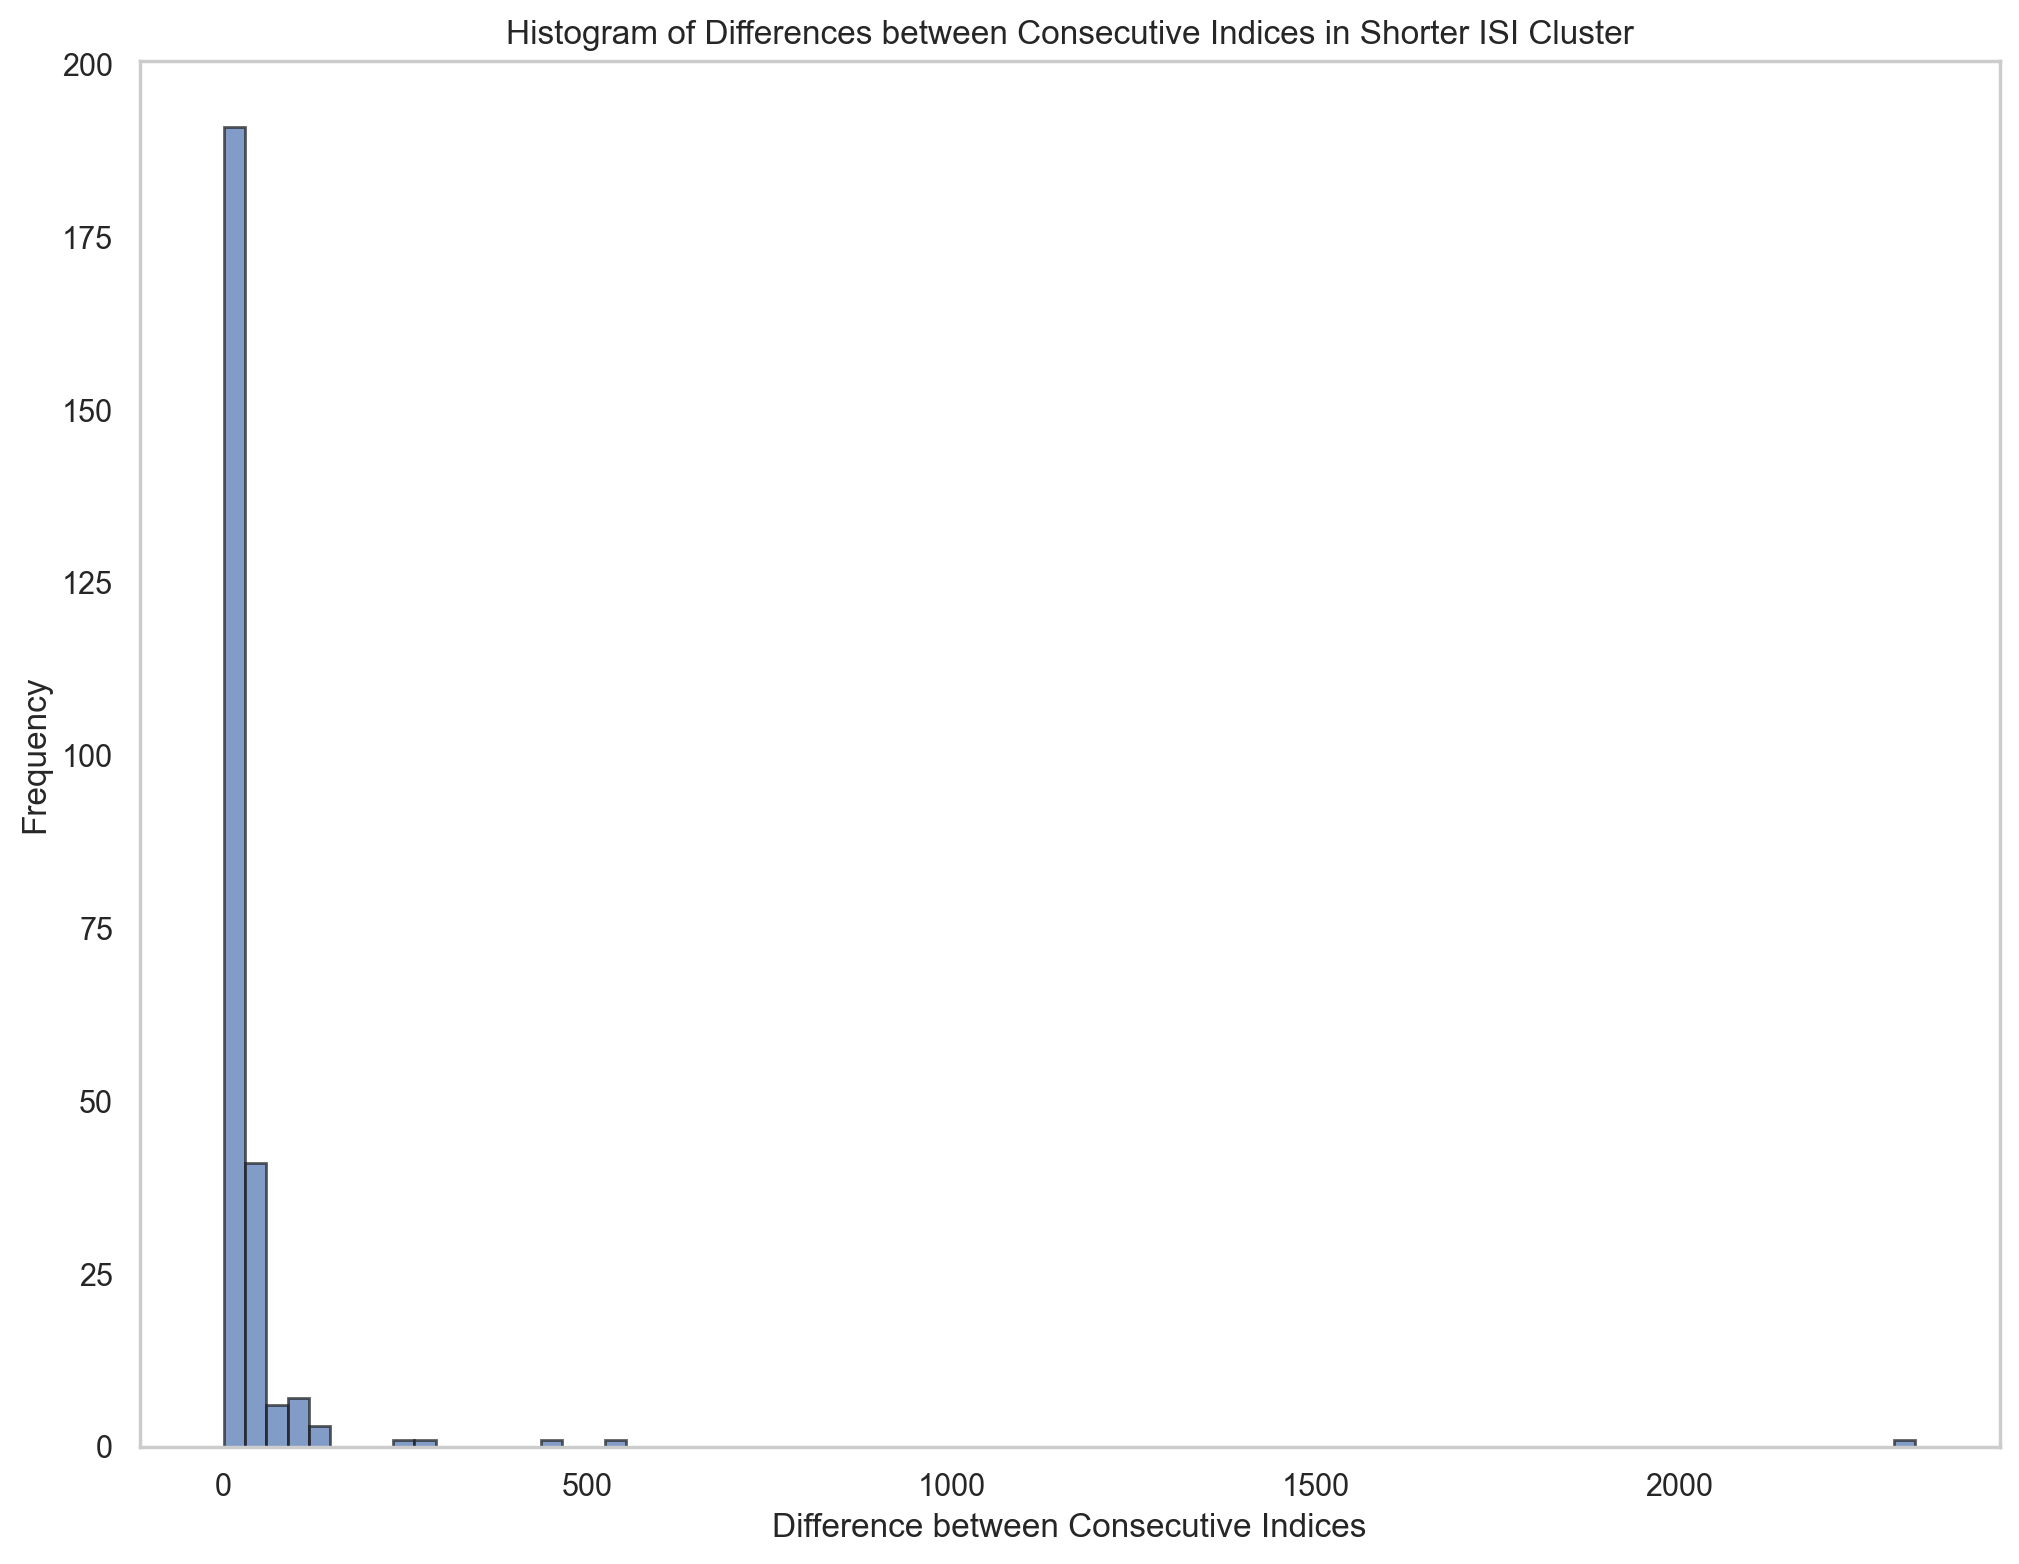

Differences between consecutive indices (longer ISI cluster): [  3 765  15  86 216  24  66 370  74   4  62  13   6  50 167  44 192  87
  35  44   7   4  15  13   7  25   8  20   8  10   8   2  18  19  26  20
  10  47  17  28  23   5  45   7   7  12  16   9  14  18   4   3  12  19
   8  16   9  41  34   7  16  24   8  22   6  13   5  22   5  12   9   3
   4  19   3  43   6   4  12  14   7  17   5   3   4   7  23  22  19   6
  20   3  16   6  27   6  20  11   6   9  11  26   4   3   4  24   3   3
  17  11   9  14  15  23   2   2  23  31   2  31   4  12   9   4   9   4
   2  10   3  23   3  15   5  17  28  28  12   4  41   7   6  11  20  14
  22  25   6  10   7   9  23   4   9   3   6  13   9   4   2   8  30  14
  11  28   6   3  33  13  25   3  27   6  12   8  10   8   3  14  36  32
  17  11  17   3  20  23   6   9  12  22   6   9   5   4   5   3   3   7
  18   2  37   5  21  11   7   3  14   3   3  13  12  13  11  31   4  10
   3   7   6  11   2  21   3   3  10   3  21  16   6   7   3  

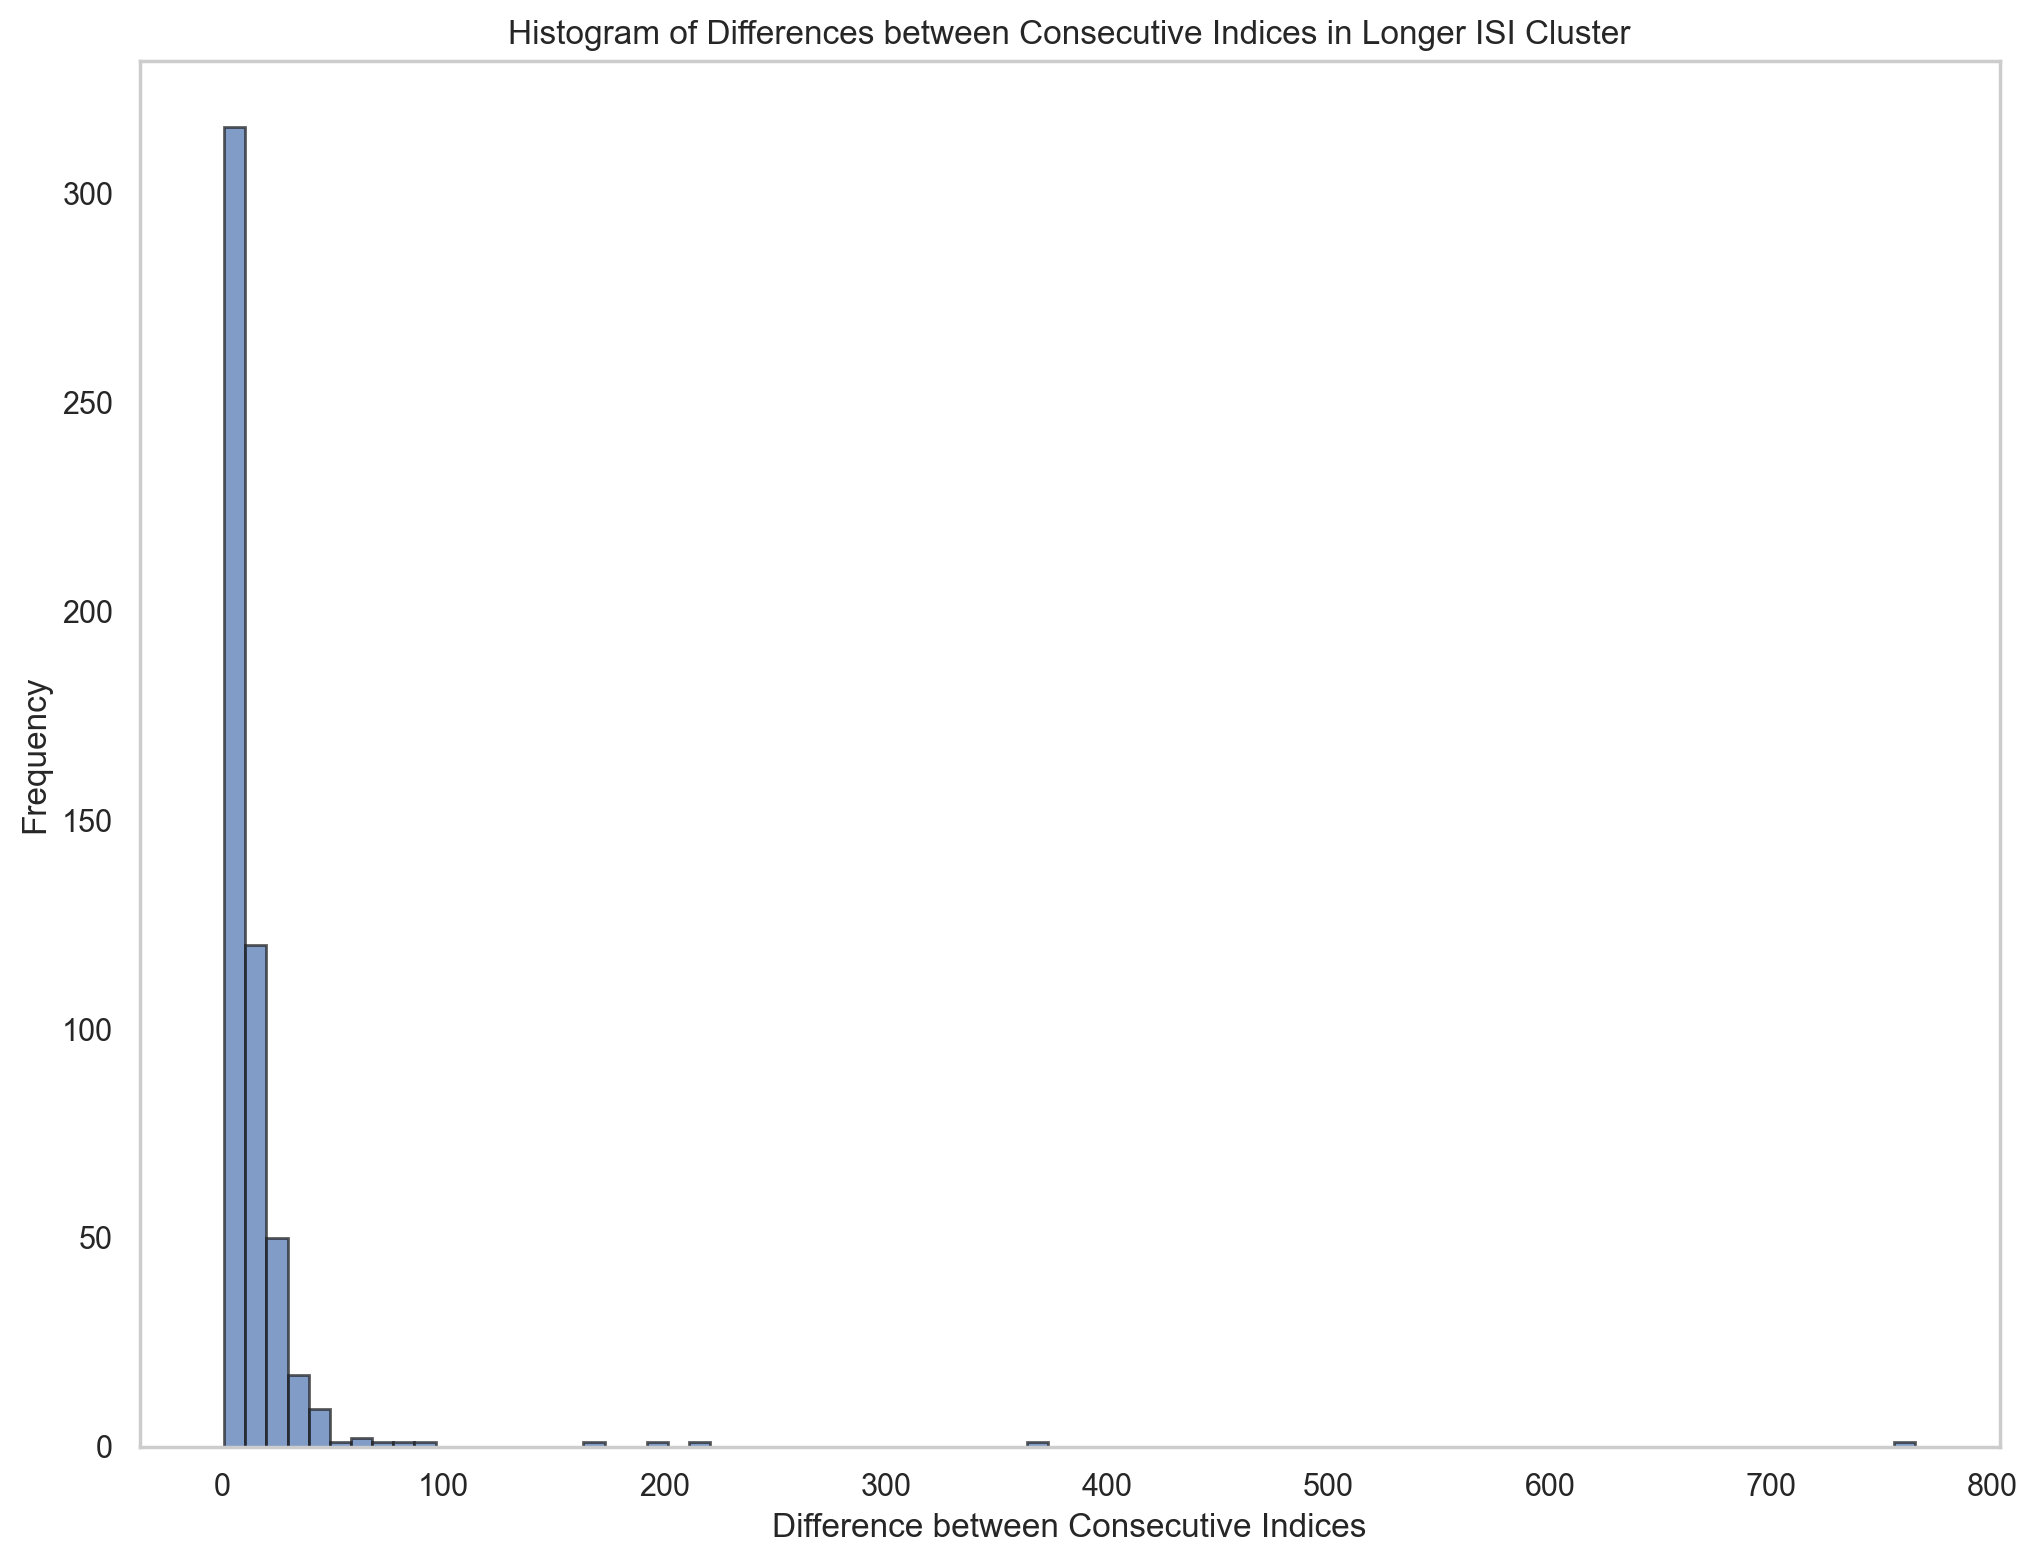

In [44]:
# Add cluster labels to the DataFrame
df_features['cluster'] = clusters

# Split data into clusters
df_cluster_0 = df_features[df_features['cluster'] == 0]
df_cluster_1 = df_features[df_features['cluster'] == 1]

# Determine which cluster has shorter ISIs
mean_isi_cluster_0 = np.mean(df_cluster_0['log_isi'])
mean_isi_cluster_1 = np.mean(df_cluster_1['log_isi'])

print(f"Mean ISI for Cluster 0: {mean_isi_cluster_0}")
print(f"Mean ISI for Cluster 1: {mean_isi_cluster_1}")

# Identify the cluster with shorter ISIs
shorter_isi_cluster = 0 if mean_isi_cluster_0 < mean_isi_cluster_1 else 1
longer_isi_cluster = 1 if shorter_isi_cluster == 0 else 0

print(f"Cluster with shorter ISIs: {shorter_isi_cluster}")

# Extract original indices for both clusters
if shorter_isi_cluster == 0:
    shorter_isi_indices = df_cluster_0['original_index']
    longer_isi_indices = df_cluster_1['original_index']
else:
    shorter_isi_indices = df_cluster_1['original_index']
    longer_isi_indices = df_cluster_0['original_index']

print(f"Indices of spikes with shorter ISIs: {shorter_isi_indices.values}")
print(f"Indices of spikes with longer ISIs: {longer_isi_indices.values}")

# Analyze indices for bursts
# Check if indices are sequential or almost sequential for shorter ISI cluster
sorted_indices_shorter = np.sort(shorter_isi_indices.values)
differences_shorter = np.diff(sorted_indices_shorter)
print(f"Differences between consecutive indices (shorter ISI cluster): {differences_shorter}")

# Plot histogram of differences to visualize the burst pattern for shorter ISI cluster
plt.hist(differences_shorter, bins=80, edgecolor='k', alpha=0.7)
plt.xlabel('Difference between Consecutive Indices')
plt.ylabel('Frequency')
plt.title('Histogram of Differences between Consecutive Indices in Shorter ISI Cluster')

plt.show()

# Check if indices are sequential or almost sequential for longer ISI cluster
sorted_indices_longer = np.sort(longer_isi_indices.values)
differences_longer = np.diff(sorted_indices_longer)
print(f"Differences between consecutive indices (longer ISI cluster): {differences_longer}")

# Plot histogram of differences to visualize the burst pattern for longer ISI cluster
plt.hist(differences_longer, bins=80, edgecolor='k', alpha=0.7)
plt.xlabel('Difference between Consecutive Indices')
plt.ylabel('Frequency')
plt.title('Histogram of Differences between Consecutive Indices in Longer ISI Cluster')

plt.show()

In [45]:
# Extract spike times (original indices) for both clusters
if shorter_isi_cluster == 0:
    shorter_isi_indices = df_cluster_0['original_index']
    longer_isi_indices = df_cluster_1['original_index']
else:
    shorter_isi_indices = df_cluster_1['original_index']
    longer_isi_indices = df_cluster_0['original_index']

print(f"Indices of spikes with shorter ISIs: {shorter_isi_indices.values}")
print(f"Indices of spikes with longer ISIs: {longer_isi_indices.values}")


Indices of spikes with shorter ISIs: [ 318 2642 2686 2794 3332 3369 3461 3912 4014 4039 4074 4103 4107 4203
 4221 4235 4354 4629 4632 4666 4715 4734 4740 4743 4780 4843 4871 4911
 5014 5256 5383 5389 5410 5414 5419 5423 5462 5491 5524 5573 5621 5642
 5646 5649 5662 5676 5682 5714 5727 5749 5752 5755 5809 5826 5836 5845
 5901 5934 5993 6065 6206 6209 6215 6238 6244 6248 6285 6333 6337 6374
 6400 6416 6461 6464 6467 6477 6508 6544 6611 6640 6644 6664 6680 6686
 6687 6692 6715 6795 6828 6829 6833 6841 6849 6855 6886 6906 6912 6918
 6924 6929 6932 6933 6955 7014 7086 7107 7120 7140 7149 7239 7247 7267
 7279 7283 7284 7288 7308 7331 7335 7339 7351 7364 7369 7372 7394 7401
 7419 7429 7459 7515 7551 7560 7564 7567 7606 7634 7656 7659 7673 7682
 7690 7700 7708 7713 7731 7749 7777 7785 7789 7814 7917 7923 7953 7964
 7965 7966 7969 7976 7979 8027 8064 8122 8158 8228 8244 8256 8290 8300
 8342 8373 8381 8413 8428 8442 8444 8469 8474 8483 8496 8534 8560 8564
 8586 8589 8592 8599 8605 8621 8641 8650

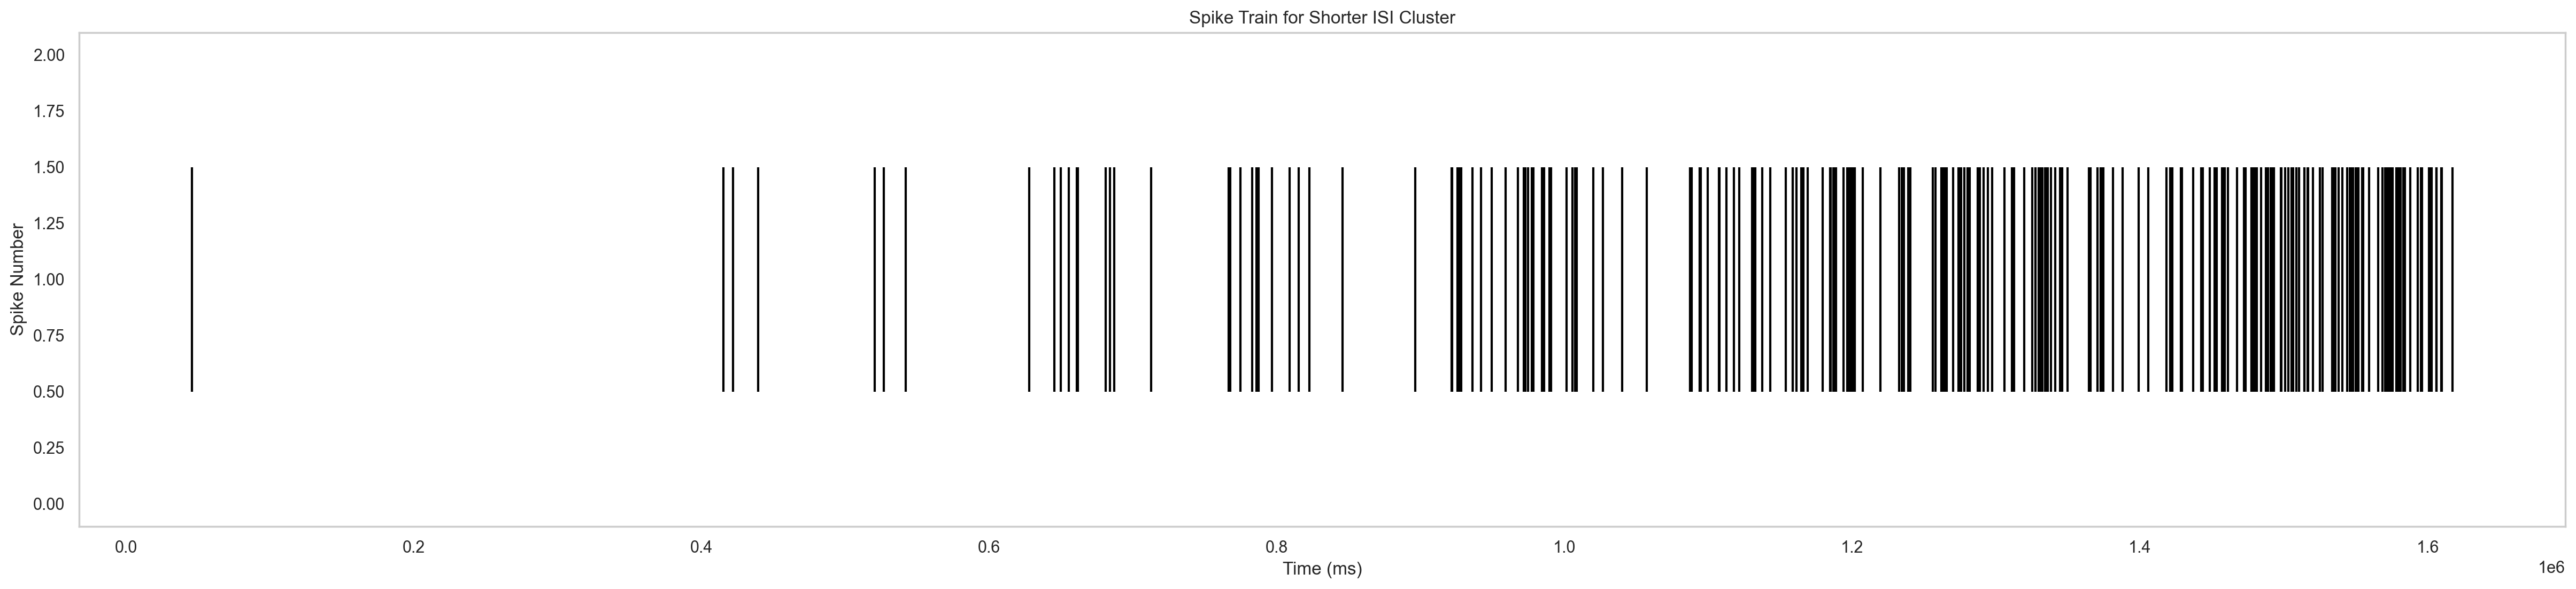

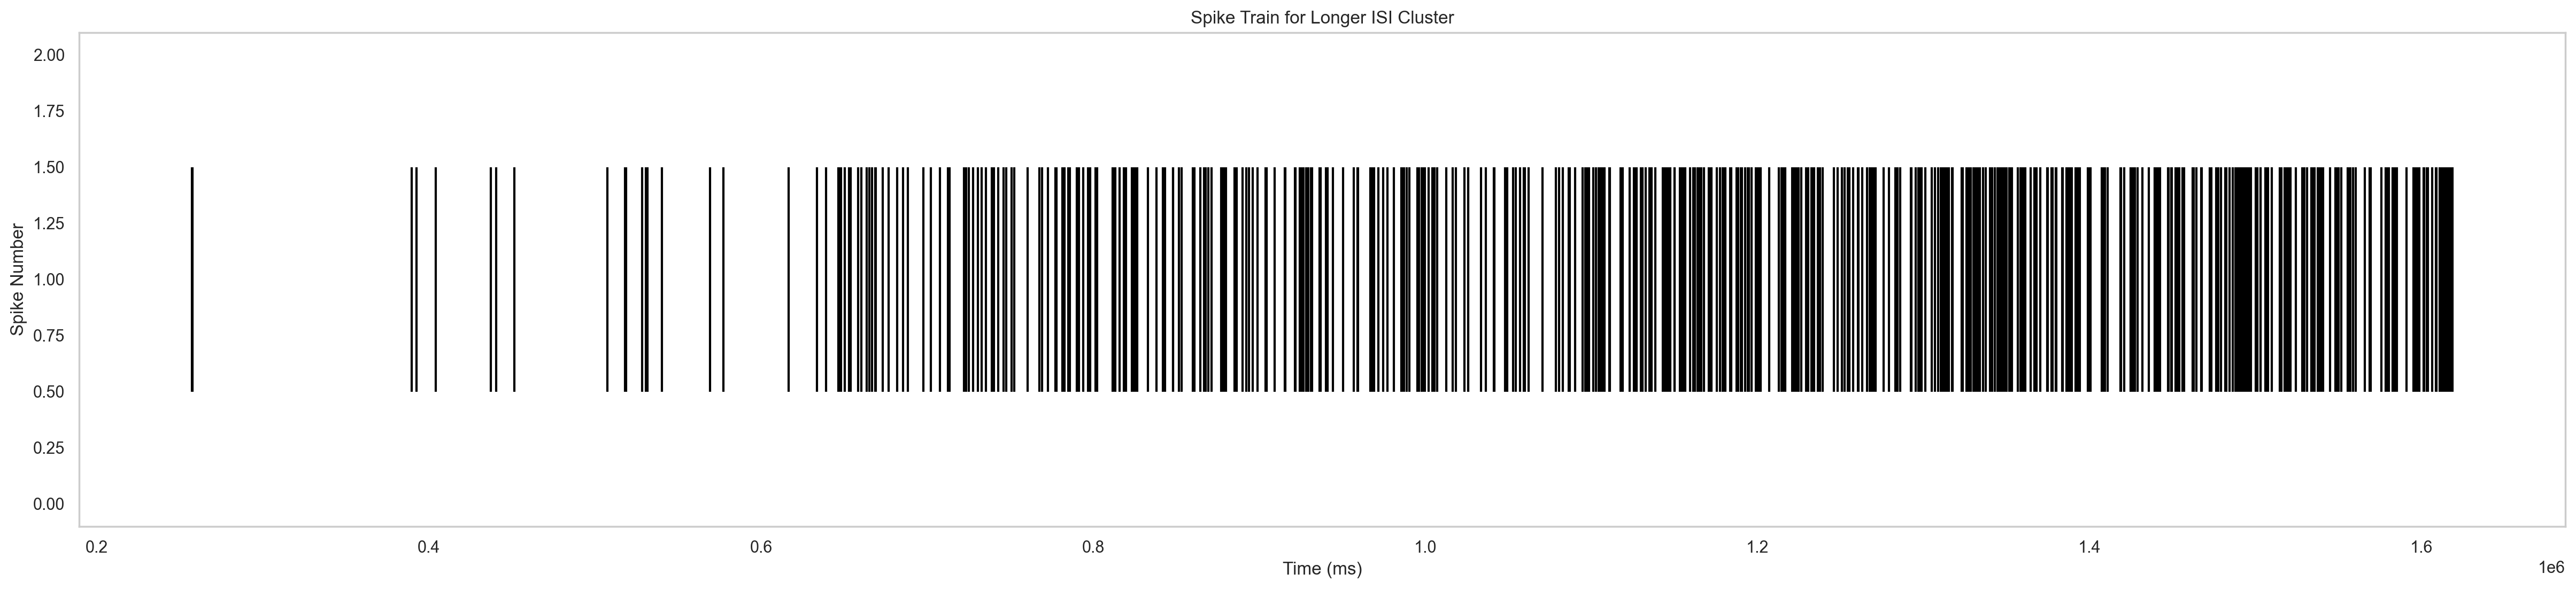

In [46]:

# Function to plot raster plot
def plot_raster(spike_indices, title):
    plt.figure(figsize=(30, 19))
    plt.eventplot(patch_times_c19[sp.spike_inds[spike_indices]], orientation='horizontal', colors='black')
    plt.xlabel('Time (ms)')
    plt.ylabel('Spike Number')
    plt.title(title)
    plt.show()

# Plot raster plots for both clusters
plot_raster(sorted_indices_shorter, 'Spike Train for Shorter ISI Cluster')
plot_raster(sorted_indices_longer, 'Spike Train for Longer ISI Cluster')


## Since the differences in the 3 models are mot stat sig - move forward just with the model without clustering based on ISI?

### Visualize model results 

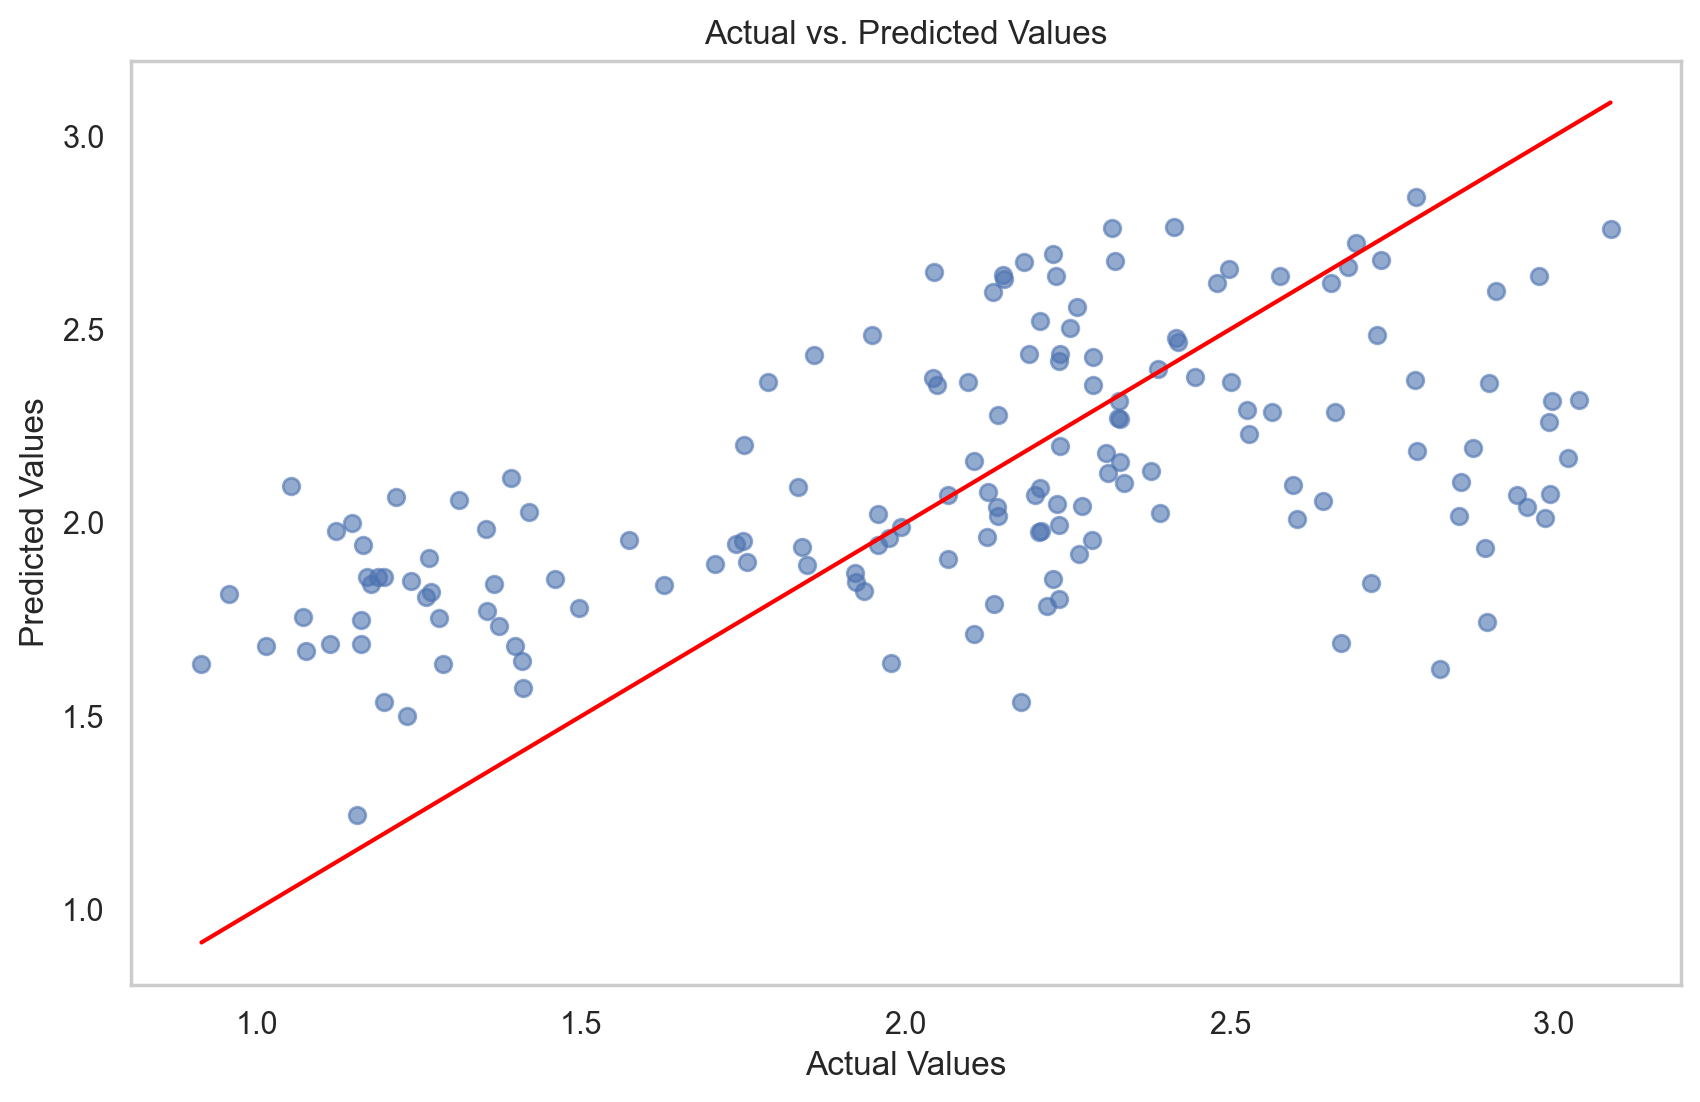

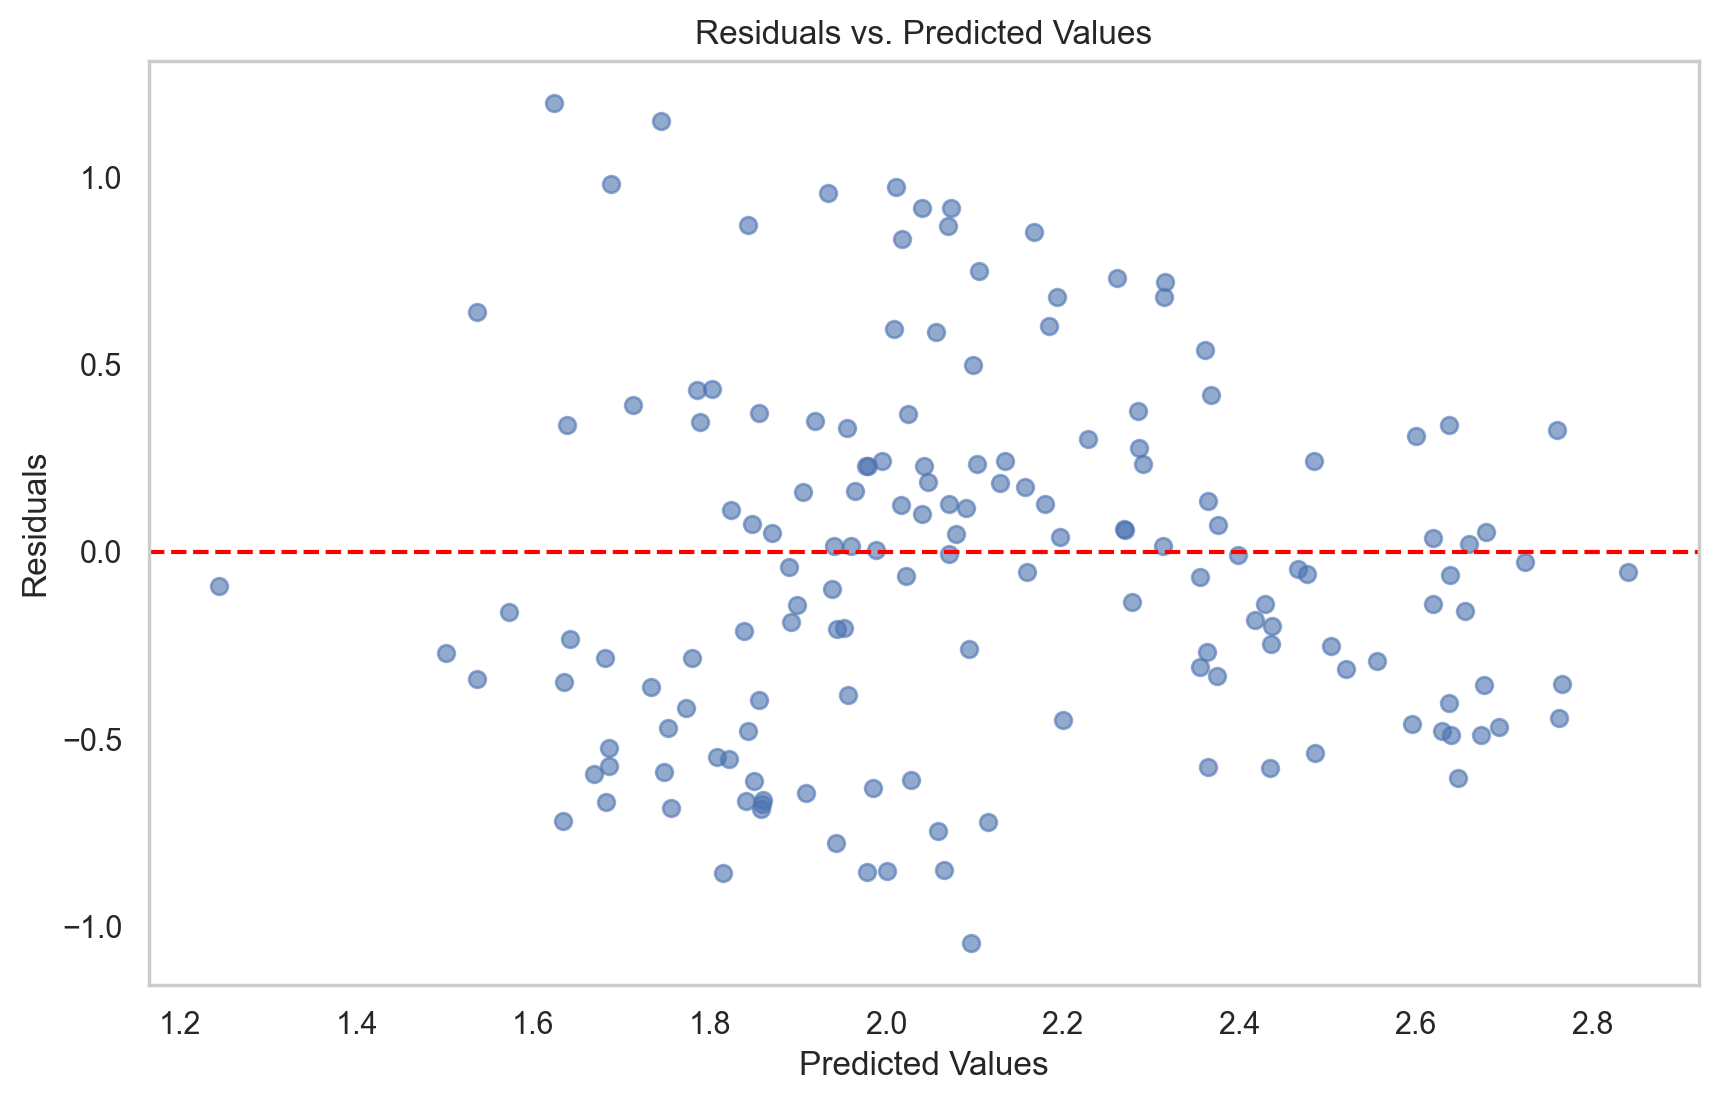

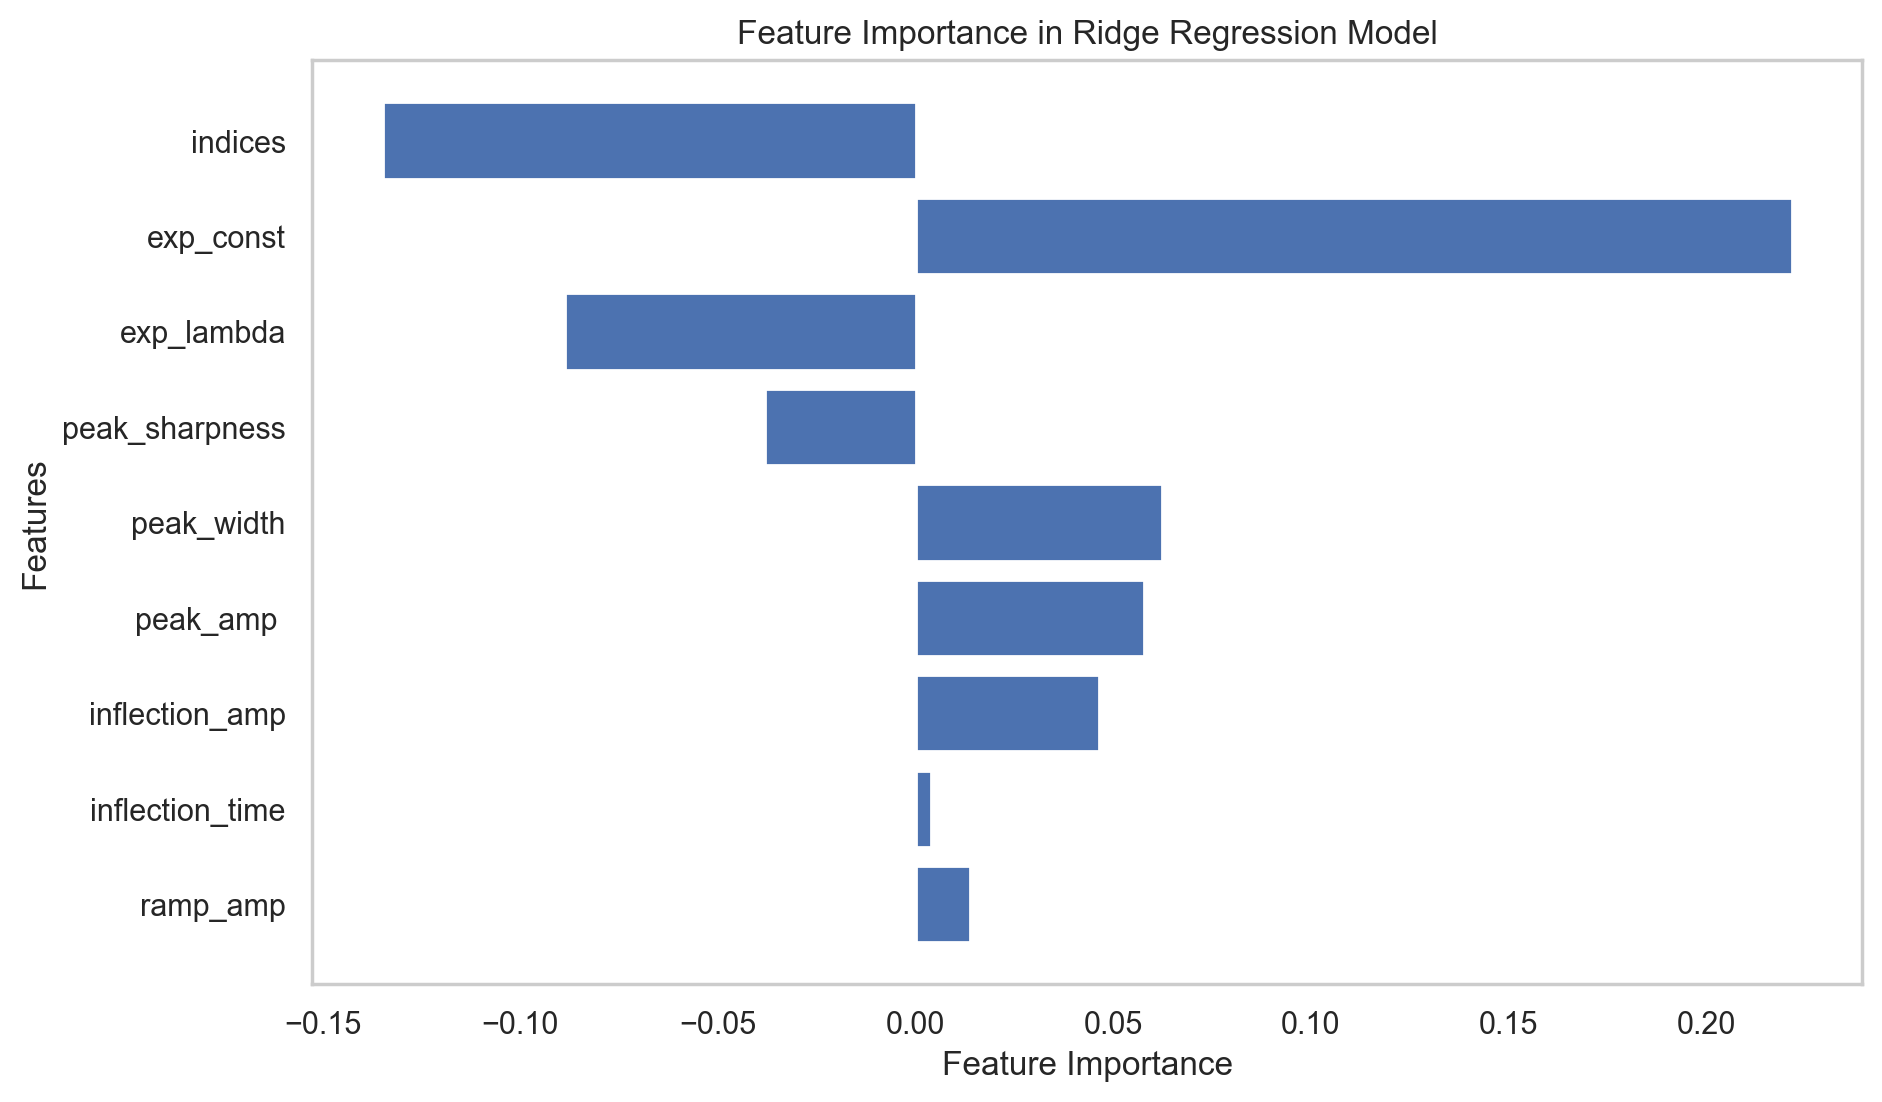

In [47]:
# Visualization of predictions
plt.figure(figsize=(10, 19))
plt.scatter(y_test, predictions_all, alpha=0.19)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red')  # 45-degree line
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted Values')
plt.show()

# Visualization of residuals
residuals = y_test - predictions_all
plt.figure(figsize=(10, 19))
plt.scatter(predictions_all, residuals, alpha=0.19)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs. Predicted Values')
plt.show()

# Feature importance
feature_importance = model.coef_

actual_feature_names = ['ramp_amp', 'inflection_time', 	'inflection_amp', 	'peak_amp ',	'peak_width', 	'peak_sharpness', 	'exp_lambda', 	'exp_const', 'indices']  # replace with your actual feature names

plt.figure(figsize=(10, 19))
plt.barh(np.arange(len(feature_importance)), feature_importance)
plt.yticks(np.arange(len(feature_importance)), actual_feature_names )  # Replace with actual feature names
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title('Feature Importance in Ridge Regression Model')
plt.show()


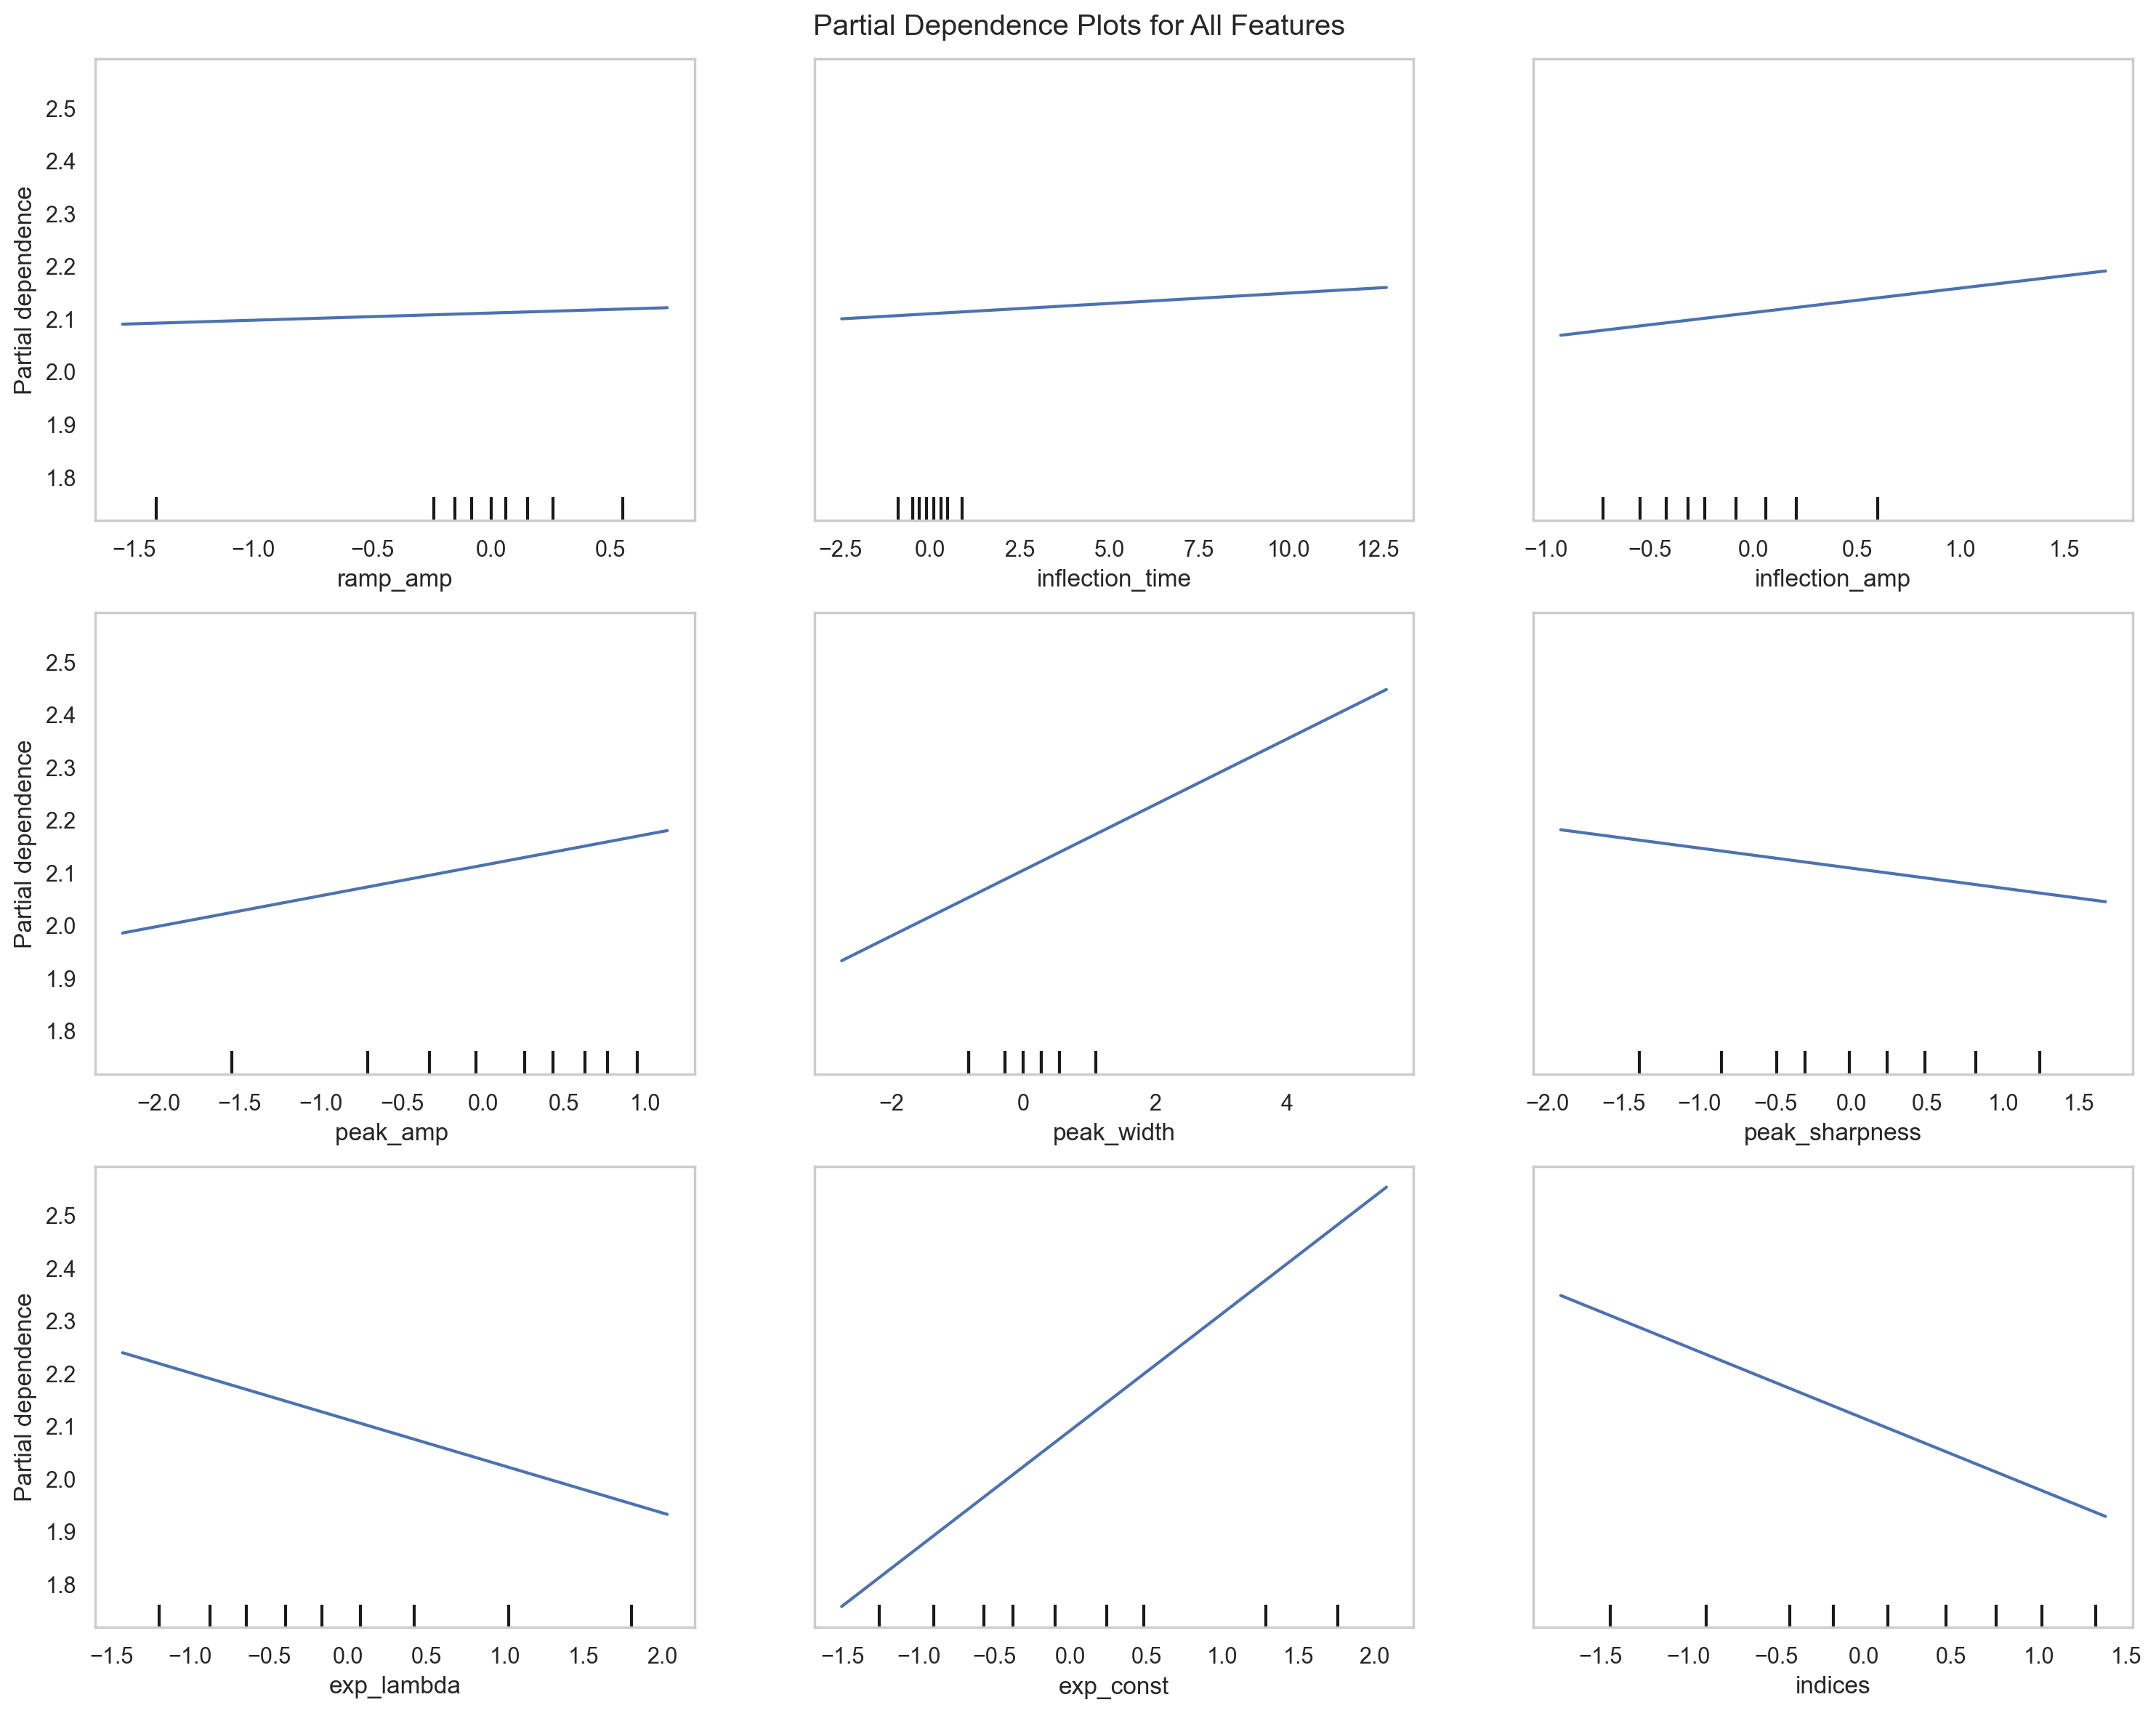

In [48]:
#FEATURE PARTIAL DEPENDANCE

from sklearn.inspection import PartialDependenceDisplay

# Create PDP for all features
fig, ax = plt.subplots(figsize=(15, 12))
PartialDependenceDisplay.from_estimator(model, X_test, range(len(actual_feature_names)), feature_names=actual_feature_names, ax=ax)
plt.suptitle('Partial Dependence Plots for All Features')
plt.tight_layout()
plt.show()


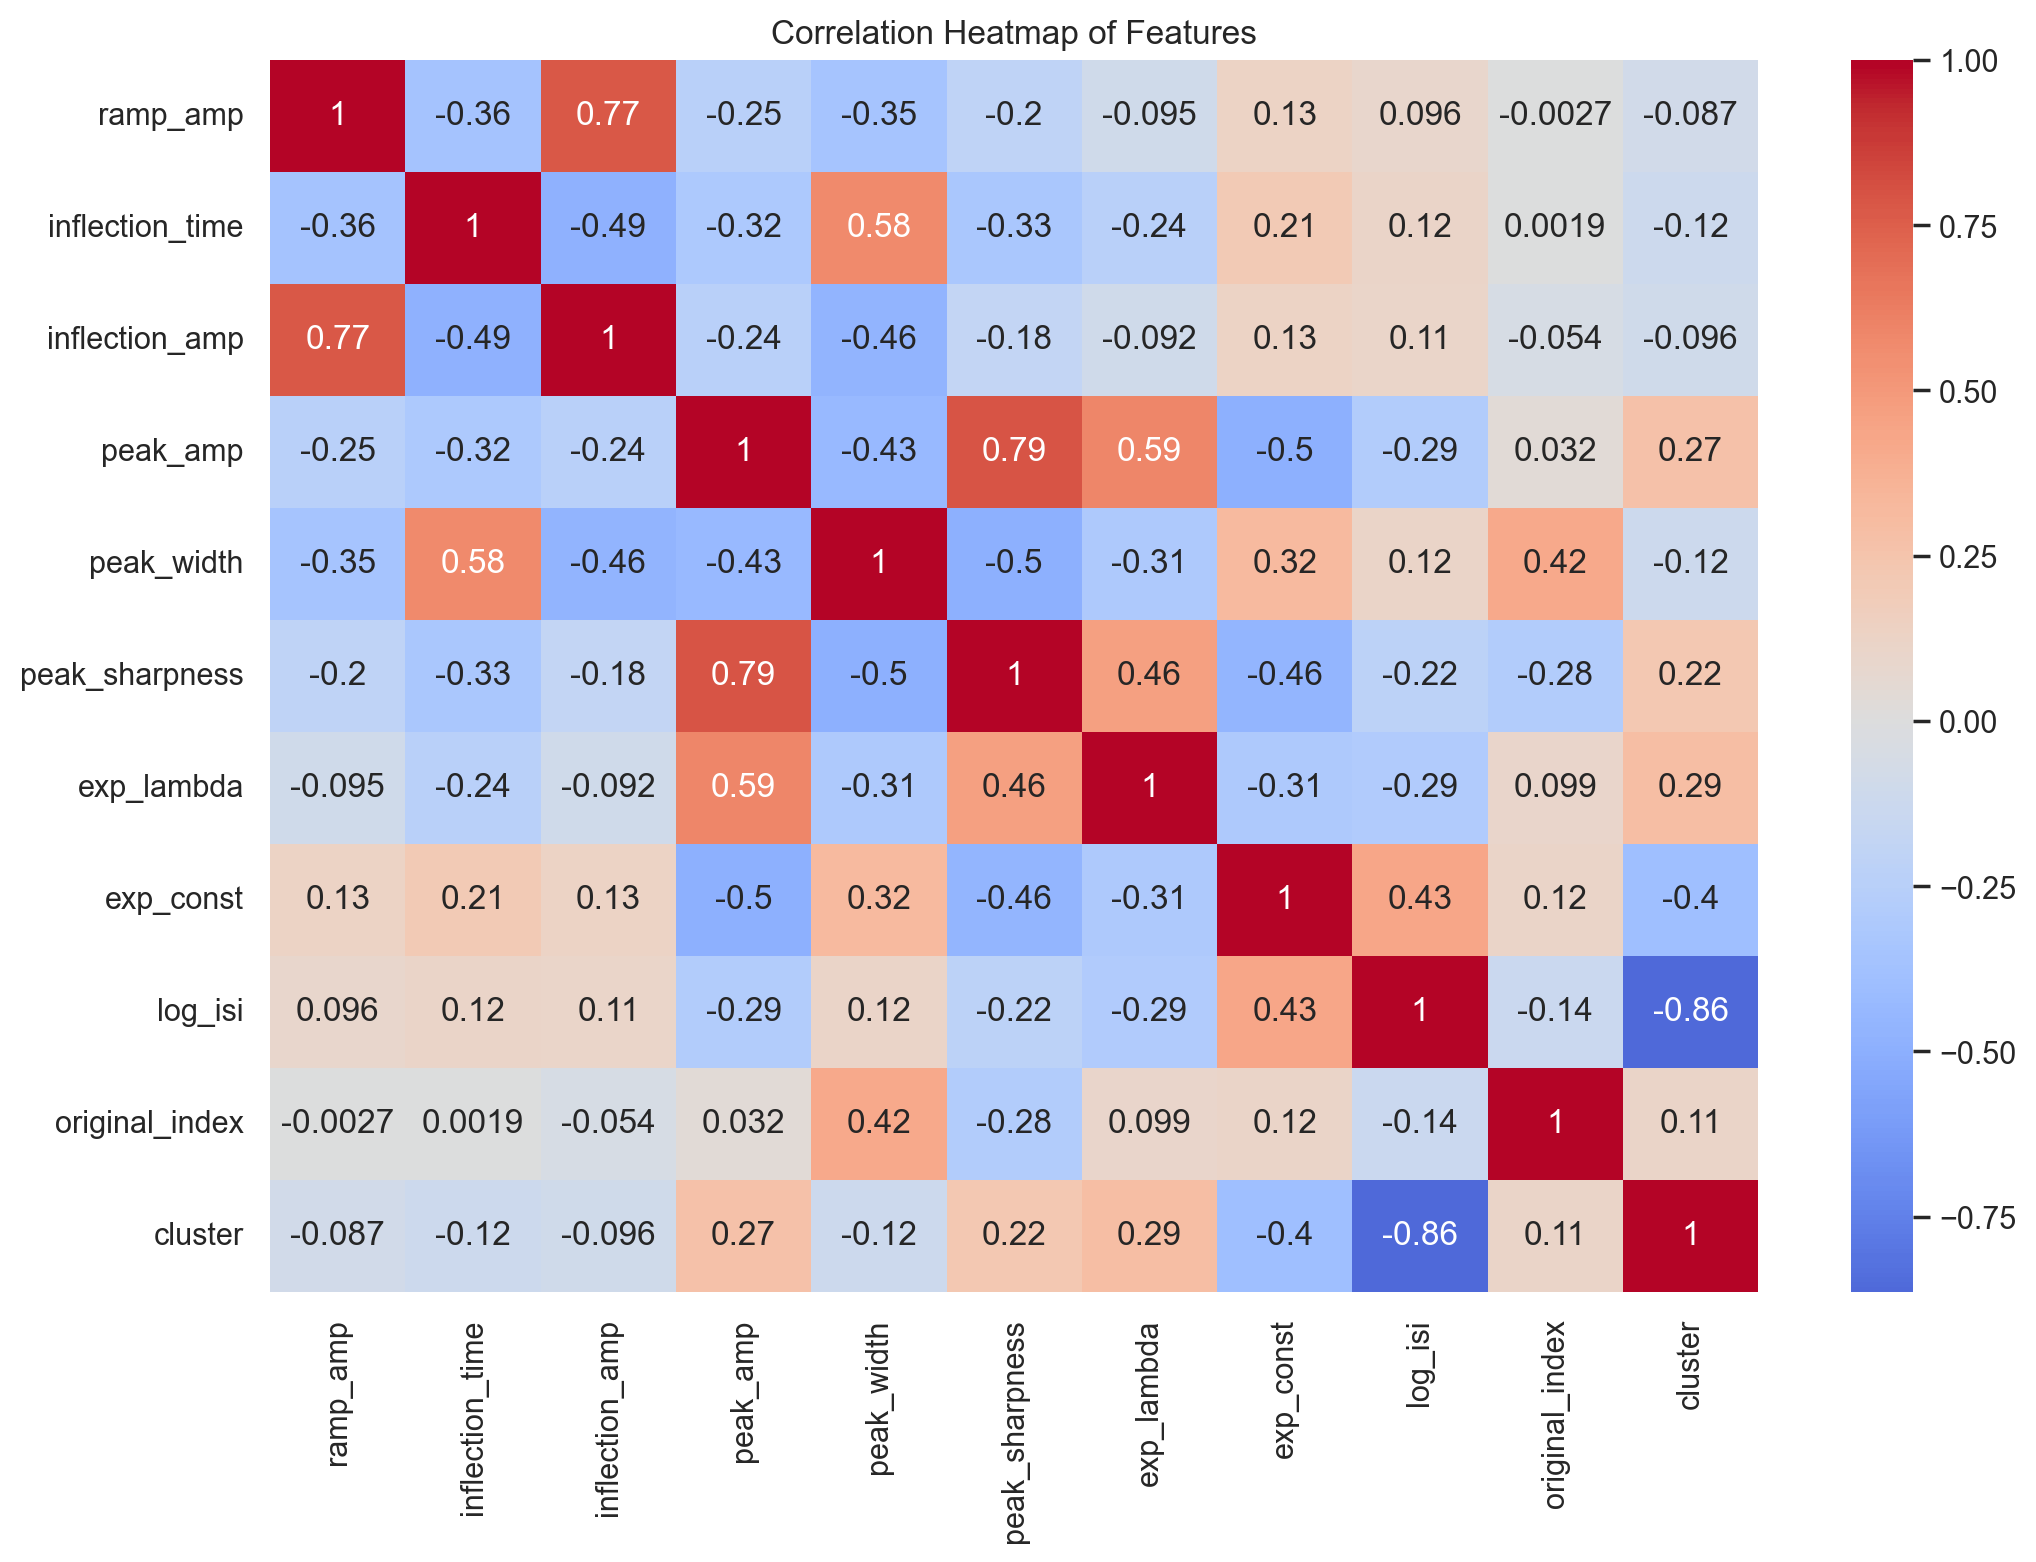

In [49]:
#see correlation matrix with orginal_index "feature"

correlation_matrix = df_features.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap of Features')
plt.show()